In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import cm
from matplotlib.colors import ListedColormap
import h5py
import random
from skimage.transform import resize
from scipy.interpolate import UnivariateSpline
# --- Path Configuration ---
# Uses pathlib for robust, OS-agnostic path handling
# Notebook: .../ROC_CI_pred/python_notebooks/Fig.3_plotPosteriors.ipynb
# Parent:   .../ROC_CI_pred/
current_dir = Path.cwd()
project_root = current_dir.parent.parent 
#ppath = project_root / "data"          # Points to .../ROC_CI_pred/data
ppath = Path("/Users/glengyel/Library/CloudStorage/GoogleDrive-lengyel.gaabor@gmail.com/My Drive/ROC_CI_pred/data")
save_fig_path = project_root / "plots" # Points to .../ROC_CI_pred/plots

# Ensure the plots directory exists
save_fig_path.mkdir(parents=True, exist_ok=True)

# --- Colormap Configuration ---
# Modern way to resample colormaps without manual linspace
clist = []
for cname in ["winter", "spring"]:
    clist.append(plt.get_cmap(cname).resampled(10))

# --- Figure Parameters ---
FigParams = {
    "fig_size": 6,
    "font1": {"fontname": "Arial", "size": 30},
    "font2": {"fontname": "Arial", "size": 30},
    "line_w": 2,
    "colors_maps": clist,
    "colors_names": ["royalblue", "olivedrab", "darkorange", "firebrick"],
    "saveFigPath": str(save_fig_path),
    "ErrorBar": {
        'ErrDist': [0.4, 0.4],
        'ErrSize': 1,
        'ErrWid': 4,
        'sizedots': 10,
        'ErrColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'DotsColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'sizeMean': 25
    },
}

def packParams():
    return (
        FigParams["fig_size"],
        FigParams["font1"],
        FigParams["font2"],
        FigParams["line_w"],
        FigParams["colors_maps"],
        FigParams["colors_names"],
        FigParams["saveFigPath"],
    )

parula_map = plt.get_cmap('viridis') 


In [5]:
(figS, f_font1, f_font2, line_w, clist, colors_names, sp) = packParams()

# Loading simulated predictions across CS directions

In [6]:
# open the file in read mode
file_path = ppath / 'MF_all_full.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    meanfire0 = file['meanfire'][:,:,2,0,:,:,:]
    meanfire1 = file['meanfire'][:,:,2,3,:,:,:]
    meanfire0 = np.array(meanfire0)
    print(meanfire0.shape)
    meanfire1 = np.array(meanfire1)
    print(meanfire1.shape)

['meanfire']
(61, 61, 3, 500, 9)
(61, 61, 3, 500, 9)


In [7]:
# open the file in read mode
file_path = ppath / 'MF_5subj_full.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))
    # access a dataset
    smeanfire0 = file['meanfire'][:,:,2,0,:,:,:]
    smeanfire1 = file['meanfire'][:,:,2,3,:,:,:]
    smeanfire0 = np.array(smeanfire0)
    print(smeanfire0.shape)
    smeanfire1 = np.array(smeanfire1)
    print(smeanfire1.shape)

['meanfire']
(61, 61, 3, 5, 9)
(61, 61, 3, 5, 9)


In [8]:
# ==========================================
# 1. Config & Data Definitions
# ==========================================

def get_reference_data():
    """Returns dictionary of reference datasets."""
    allman_85 = np.array([[-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180],
                          [1,0.75,0.7,0.5,0.4,0.32,0.3,0.33,0.42,0.51,0.75,0.98,1],
                          [0.44,0.47,0.2,0.12,0.1,0.12,0.11,0.12,0.45,1,0.55,0.5,0.44],
                          [0.20,0.35,0.265,0.24,0.26,0.25,0.18,0.22,0.2,0.33,0.25,0.32,0.2]])

    born2000 = np.array([[-180,-135,-90,-45,0,45,90,135,180],
                         [1,0.97,0.35,0.08,0,0.05,0.53,0.98,1],
                         [0.5,0.51,0.05,0.1,0.1,0.14,0.12,0.4,0.5],
                         [0.1,0.12,0.3,1,0.97,1,0.35,0.3,0.1],
                         [0.6,0.65,0.8,1,0.95,0.85,0.8,0.58,0.6]])

    tanaka86_dir = np.array([[0,30,60,90],
                             [0.27,0.46,0.6,1],
                             [0.1,0.45,0.75,1],
                             [0.41,0.49,0.62,0.63],
                             [0.22,0.31,0.62,0.8]])
    
    return {'allman': allman_85, 'born': born2000, 'tanaka': tanaka86_dir}

def get_example_indices():
    """Returns dictionary of example indices used in plots."""
    return {
        'allman': [(2, 135, 7), (0, 176, 6), (1, 328, 1), (2, 328, 1), (0, 328, 1)],
        'born': [(1, 11, 6), (0, 197, 2), (0 ,227, 4), (2, 62, 5)],
        'tanaka': [(2, 63, 4), (1, 193, 5), (1, 378, 7), (2, 330, 0)],
        'chosen': [(1, 23, 1), (1, 279, 7), (2, 260, 7), (1, 423, 4), (1, 250, 1),
                   (2, 290, 1), (1, 383, 1), (1, 355, 1), (1, 291, 4)]
    }

def get_colormaps(num_levels, name_list=["winter", "hot"], ranges=[(0.15, 0.65), (0.1, 0.9)]):
    """Generates colormaps for plots."""
    clist = []
    # If ranges is single tuple, repeat it
    if isinstance(ranges, tuple): ranges = [ranges] * len(name_list)
    
    for i, cname in enumerate(name_list):
        r = ranges[i] if i < len(ranges) else ranges[0]
        c = cm.get_cmap(cname, 100)
        clist.append(ListedColormap(c(np.linspace(r[0], r[1], num_levels))))
    return clist

# ==========================================
# 2. Basic Plotting Helpers
# ==========================================

def save_and_show(save_path, filename):
    if save_path:
        full_path = os.path.join(save_path, filename)
        plt.savefig(full_path)
    plt.show()

def plot_heatmap_comparison(t1, t2, ix_line_x, ix_line_y, ticks, 
                            params, line_color="r", show_diff_only=True):
    """Plots t1-t2 heatmap with dashed reference line."""
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']

    _, ax = plt.subplots(1, 1, figsize=(figS*0.5, figS*0.5))
    ax.imshow(t1 - t2, cmap=params['map'], vmin=-0.8, vmax=0.8)
    ax.plot(np.repeat(ix_line_x, len(ix_line_y)), ix_line_y, "--", color=line_color, linewidth=line_w+2)
    
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    ax.set_axis_off() # Hides all ticks/labels cleanly
        
    for labl in (ax.get_xticklabels() + ax.get_yticklabels()):
        labl.set_fontname(font["fontname"])
        labl.set_fontsize(font["size"]-2)
    plt.show()



def vector_subtract(direction1, speed1, direction2, speed2):
    x1 = speed1 * np.cos(np.radians(direction1))
    y1 = speed1 * np.sin(np.radians(direction1))
    x2 = speed2 * np.cos(np.radians(direction2))
    y2 = speed2 * np.sin(np.radians(direction2))
    
    x_diff = x1 - x2
    y_diff = y1 - y2
    
    result_speed = np.sqrt(x_diff**2 + y_diff**2)
    result_direction = np.degrees(np.arctan2(y_diff, x_diff))
    
    if result_direction >= 180: result_direction -= 360
    elif result_direction < -180: result_direction += 360
    
    return result_direction, result_speed

def plot_direction_tuning_examples(meanfire1, ixs_chosen, ixs_r, clist, params):
    """
    Plots Heatmap and Curve for specific example indices [User Snippet 1].
    """
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']
    
    tckix = [0, 30, 60]
    tckvalx = ["-180", "0", "180"]
    tckiyval = ["180", "0", "-180"]
    tckiy = [0, 0.5, 1]
    
    for ix in ixs_chosen:
        # Data Extraction
        t = meanfire1[:,:,ix[0],ix[1],ix[2]]
        t = np.flip(t.T, axis=0) # [Space, Time]
        
        # 1. Heatmap with overlaid lines
        _, ax = plt.subplots(1, 1, figsize=(figS*0.6, figS*0.6))
        ax.imshow(t, cmap=params['map'])
        
        # Overlay lines
        for i, j in enumerate(ixs_r):
            # j is index, i is color index
            ax.plot(range(t.shape[0]), np.repeat(j, t.shape[0]), "--", 
                    linewidth=line_w+2, color=clist[1](i))
            
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)
        
        ax.yaxis.set_ticks(tckix)
        ax.yaxis.set_ticklabels(tckiyval)
        ax.xaxis.set_ticks(tckix)
        ax.xaxis.set_ticklabels(tckvalx)
        
        for labl in (ax.get_xticklabels() + ax.get_yticklabels()):
            labl.set_fontname(font["fontname"])
            labl.set_fontsize(font["size"]-2)
        plt.show()
        
        # 2. Separate Curve Plot
        _, ax2 = plt.subplots(1, 1, figsize=(figS*0.6, figS*0.6))
        for i, j in enumerate(ixs_r):
            ax2.plot(t[j, :], "-", linewidth=line_w+4, color=clist[1](i))
            
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.grid(False)
        
        ax2.yaxis.set_ticks(tckiy)
        ax2.yaxis.set_ticklabels(tckiy)
        ax2.xaxis.set_ticks(tckix)
        ax2.xaxis.set_ticklabels(tckvalx)
        
        for labl in (ax2.get_xticklabels() + ax2.get_yticklabels()):
            labl.set_fontname(font["fontname"])
            labl.set_fontsize(font["size"]-2)
        plt.show()

def plot_subject_overview(meanfire1s, ixs_r, clist, params):
    """
    Plots Heatmap and Curve with Markers for 5-subject data [User Snippet 2].
    Loops over PI, NI.
    """
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']
    
    tckix = [0, 30, 60]
    tckvalx = ["-180", "0", "180"]
    xr = [0, 7, 15, 22, 30, 37, 45, 52, 60]
    
    # Iterate P, N
    P, N = meanfire1s.shape[3], meanfire1s.shape[4]
    
    for pi in range(P):
        for ni in range(N):
            # Data Extraction (Element 0 fixed as per snippet)
            t = meanfire1s[:,:,0,pi,ni]
            t = np.flip(t.T, axis=0)
            
            # 1. Heatmap
            _, ax = plt.subplots(1, 1, figsize=(figS*0.6, figS*0.6))
            ax.imshow(t, cmap=params['map'])
            
            for i, j in enumerate(ixs_r):
                ax.plot(range(t.shape[0]), np.repeat(j, t.shape[0]), "--", 
                        linewidth=line_w+2, color=clist[1](i))
                
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(False)
            
            ax.yaxis.set_ticks([]) # Hidden in snippet 2
            ax.xaxis.set_ticks(tckix)
            ax.xaxis.set_ticklabels(tckvalx)
            
            for labl in (ax.get_xticklabels() + ax.get_yticklabels()):
                labl.set_fontname(font["fontname"])
                labl.set_fontsize(font["size"]-2)
            
            ax.tick_params(axis='x', which='major', pad=12)
            plt.show()
            
            # 2. Curve with Markers
            _, ax2 = plt.subplots(1, 1, figsize=(figS*0.6, figS*0.6))
            for i, j in enumerate(ixs_r):
                # Line
                ax2.plot(t[j, :], "-", linewidth=line_w+4, color=clist[1](i))
                # Markers on 'xr' indices
                ax2.plot(xr, t[j, xr], "o", markersize=10, 
                         color=clist[1](i), markeredgecolor="k")
                
            ax2.spines["top"].set_visible(False)
            ax2.spines["right"].set_visible(False)
            ax2.grid(False)
            
            ax2.yaxis.set_ticks([]) # Hidden
            ax2.xaxis.set_ticks(tckix)
            ax2.xaxis.set_ticklabels(tckvalx)
            
            for labl in (ax2.get_xticklabels() + ax2.get_yticklabels()):
                labl.set_fontname(font["fontname"])
                labl.set_fontsize(font["size"]-2)
            plt.show()

def plot_shift_violin_final(shift_s, ixs_r, clist, params):
    """
    Violin plot of shifts [User Snippet 3].
    """
    figS = params['figS']
    line_w = params['line_w']
    font = params['font']
    sp = params.get('sp')
    
    # Prepare Data: Wrapping [0,1,2,3,0]
    # Remove NaNs
    s = [
        shift_s[~np.isnan(shift_s[:,0]), 0],
        shift_s[~np.isnan(shift_s[:,1]), 1],
        shift_s[~np.isnan(shift_s[:,2]), 2],
        shift_s[~np.isnan(shift_s[:,3]), 3],
        shift_s[~np.isnan(shift_s[:,0]), 0]
    ]
    
    positions = [180, 90, 0, -90, -180]
    half_width = 60 # approx width_factor in snippet is half_range*3 = 20*3=60
    
    colors = [clist[1](i) for i in range(len(ixs_r))]
    colors.append(clist[1](0))
    
    _, ax = plt.subplots(1, 1, figsize=(figS*1.7, figS*1.4))
    
    # Violin
    parts = ax.violinplot(s, positions, showmeans=False, showmedians=False, 
                          showextrema=False, widths=half_width)
    
    for pi, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[pi])
        pc.set_edgecolor("k")
        pc.set_alpha(0.6)
        
    # Grid Lines (Exact per snippet 3)
    limS = 215
    ax.plot((0, 0),(-limS,limS),"k--",linewidth=line_w+1)
    ax.plot((-limS, limS),(0,0),"k--",linewidth=line_w+1)
    M = 18
    ax.plot((-limS, limS),(M,M),"k:",linewidth=line_w+1, alpha=0.5)
    ax.plot((-limS, limS),(-M,-M),"k:",linewidth=line_w+1, alpha=0.5)
    
    # Diagonals
    ax.plot([-180,-90],[0,90],"b--",linewidth=line_w+1, alpha=0.8)
    ax.plot([90,180],[-90,0],"b--",linewidth=line_w+1, alpha=0.8)
    ax.plot([-90,90],[90,-90],"b--",linewidth=line_w+1, alpha=0.8)
    
    # Scatter Overlay
    n2 = len(shift_s) # Total samples before nan filter
    # Note: Shift_s still contains NaNs where not matching std criteria in calculation?
    # Actually 's' above is filtered. Scatter uses 'shift_s' raw with random jitter
    # Range of indices is ixs_r_deg[:-1] -> [180, 90, 0, -90]
    # And manual last one.
    
    jitter_range = 10
    
    for i, j in enumerate(positions[:-1]): # First 4
        # Need aligned shift_s column i
        # shift_s shape [N2, 4]
        vals = shift_s[:, i]
        # Filter NaNs for plotting? Snippet doesn't explicitly filter but 'plot' handles nans or 's' filtered them
        # Snippet: "shift_s[:,i]" - scatter usually ignores NaNs in matplotlib
        jitter = np.random.uniform(low=j-jitter_range, high=j+jitter_range, size=len(vals))
        ax.plot(jitter, vals, "o", color=clist[1](i), markersize=8, markeredgecolor="k")
        
    # Last one (Index 0 wrapped to -180)
    vals_0 = shift_s[:, 0]
    jitter_0 = np.random.uniform(low=-180-jitter_range, high=-180+jitter_range, size=len(vals_0))
    ax.plot(jitter_0, vals_0, "o", color=clist[1](0), markersize=8, markeredgecolor="k")
    
    # Axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    
    ticks_ax = [-90, -45, 0, 45, 90]
    ax.yaxis.set_ticks(ticks_ax)
    ax.yaxis.set_ticklabels(ticks_ax)
    
    tckix = [-180, -90, 0, 90, 180]
    ax.xaxis.set_ticks(tckix)
    ax.xaxis.set_ticklabels(tckix)
    
    for labl in (ax.get_xticklabels() + ax.get_yticklabels()):
        labl.set_fontname(font["fontname"])
        labl.set_fontsize(font["size"]-2)
        
    ax.set_xlim(-limS, limS)
    ax.set_ylim(-100, 100)
    
    if sp: plt.savefig(os.path.join(sp, 'dirShifts.pdf'))
    plt.show()

# ==========================================
# 4. Calculation Logic
# ==========================================

def calculate_shift_s(meanfire1s, ixs_r, deg0, scale_factor):
    """
    Calculates shift_s using the 'n2' loop logic over meanfire1s [Snippet 3].
    """
    P, N = meanfire1s.shape[3], meanfire1s.shape[4]
    n2 = P * N
    
    shift_s = np.zeros((n2, len(ixs_r))) + np.nan
    wix = []
    
    idx = 0
    for pi in range(P):
        for ni in range(N):
            # Element 0
            t = meanfire1s[:,:,0,pi,ni]
            t = np.flip(t.T, axis=0)
            t = t[ixs_r, :]
            
            maxix = np.argmax(t, axis=1)
            
            # Shift Calculation
            current_shifts = -(maxix - deg0) * scale_factor
            shift_s[idx, :] = current_shifts
            
            # WIX filter condition
            if np.std(current_shifts) < 30:
                # print(pi, ni)
                wix.append((pi, ni))
            
            idx += 1
            
    return shift_s, wix


# Analyzing Direction Tuning Curves

Starting Analysis...

--- Direction Heatmaps ---
Allman


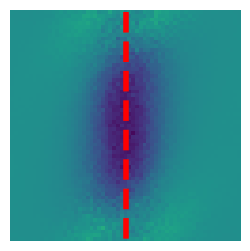

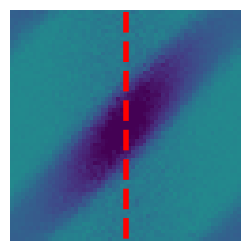

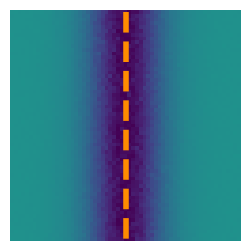

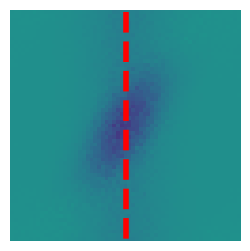

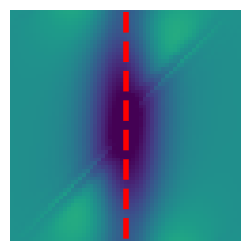

Born


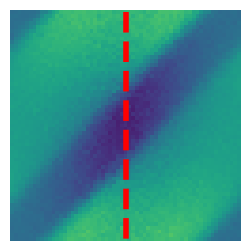

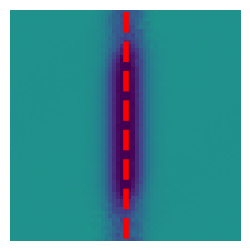

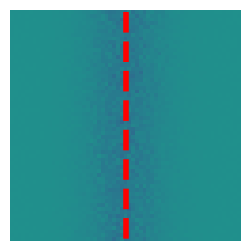

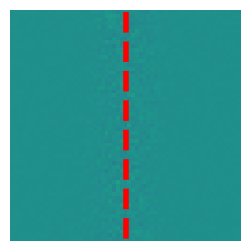

Tanaka


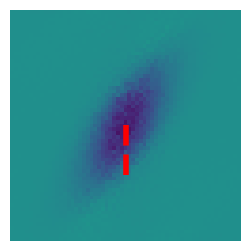

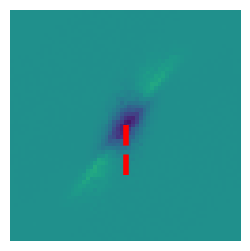

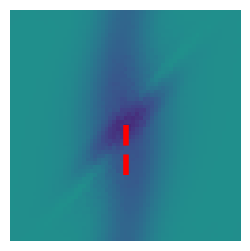

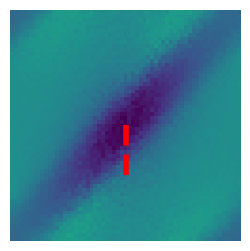

In [9]:
print("Starting Analysis...")
style = {'map': parula_map, 'figS': figS, 'line_w': line_w, 'font': f_font1, 'sp': sp}

# --- 1. Direction Heatmaps ---
print("\n--- Direction Heatmaps ---")
R = meanfire1.shape[0]
ix2_range = np.round(np.linspace(0, 60, 13)).astype(int)
ix1_center = 30

ex_indices = get_example_indices()

# Allman Loop
print("Allman")
for ix in ex_indices['allman']:
    t1 = np.flip(meanfire1[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    t2 = np.flip(meanfire0[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    lc = "darkorange" if ix[0] == 1 else "r"
    plot_heatmap_comparison(t1, t2, ix1_center, ix2_range, None, style, line_color=lc)

# Born Loop
print("Born")
for ix in ex_indices['born']:
    t1 = np.flip(meanfire1[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    t2 = np.flip(meanfire0[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    plot_heatmap_comparison(t1, t2, ix1_center, ix2_range, None, style)

print("Tanaka")
# Tanaka Loop
ix2_tanaka = [30, 34, 39, 44]
for ix in ex_indices['tanaka']:
    t1 = np.flip(meanfire1[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    t2 = np.flip(meanfire0[:,:,ix[0],ix[1],ix[2]].T, axis=0)
    plot_heatmap_comparison(t1, t2, ix1_center, ix2_tanaka, None, style)


--- Plotting Direction Examples ---


/var/folders/7v/b8fs48v95fxb7gdt_3bqj7q00000gp/T/ipykernel_53730/2023286274.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = cm.get_cmap(cname, 100)


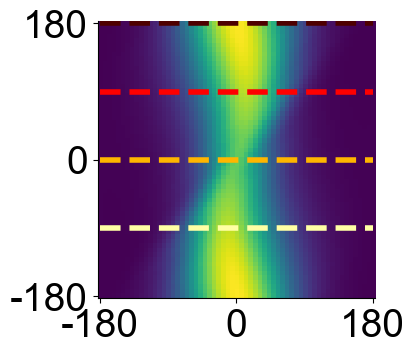

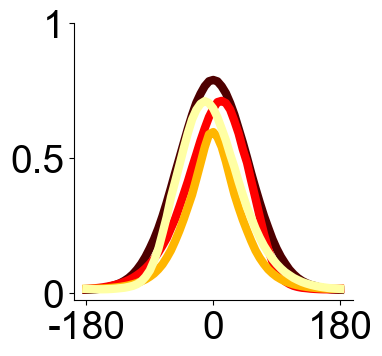

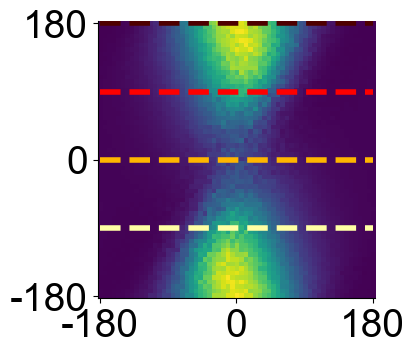

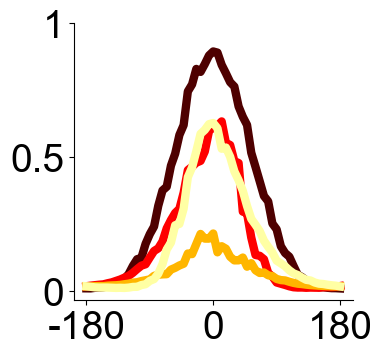

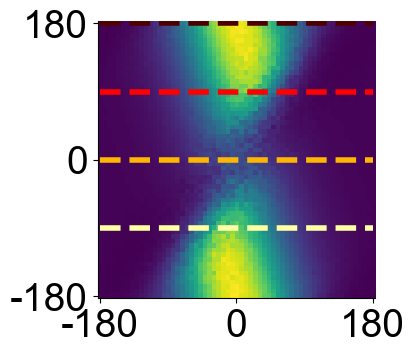

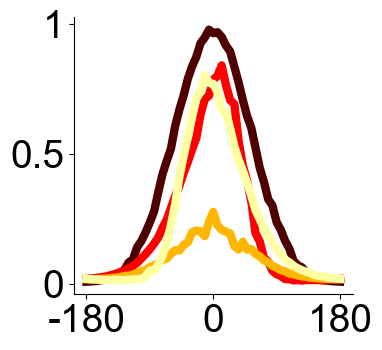

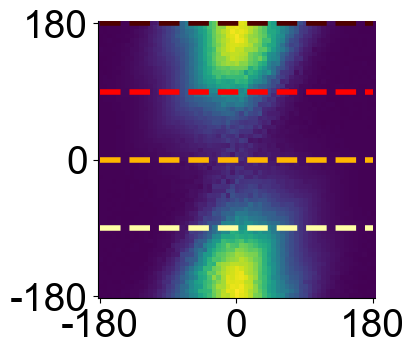

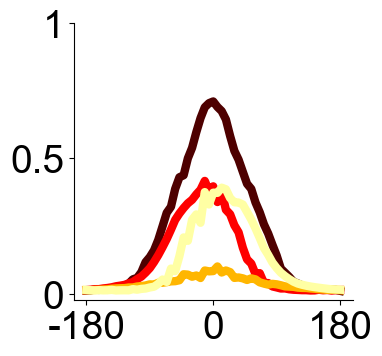

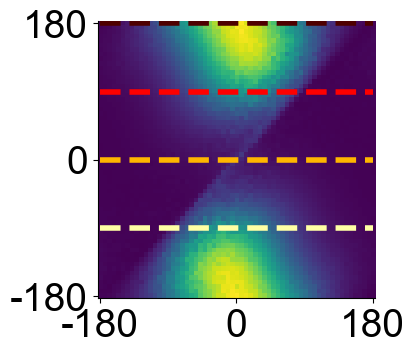

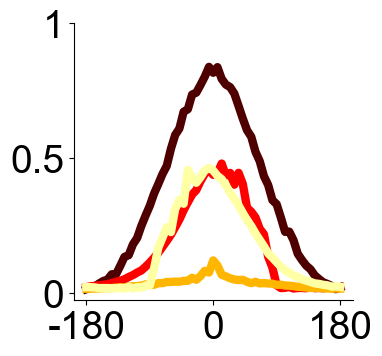

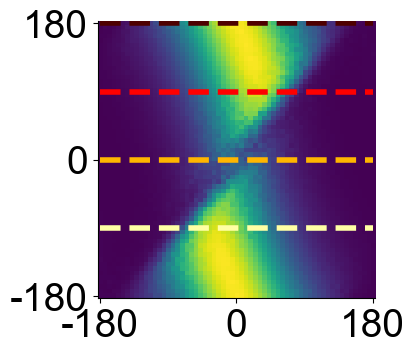

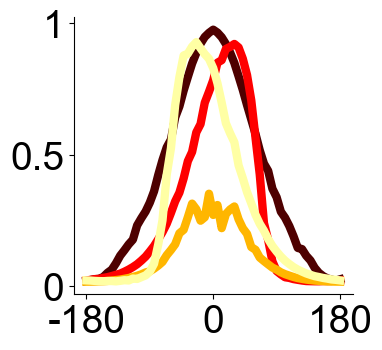

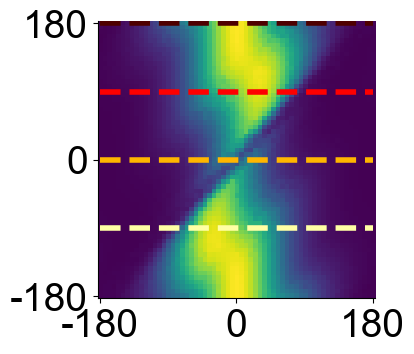

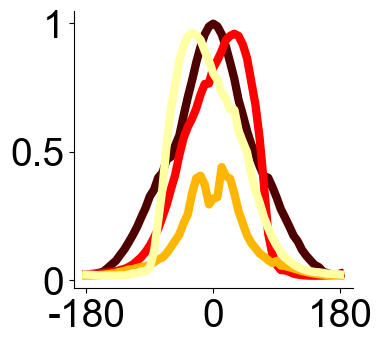

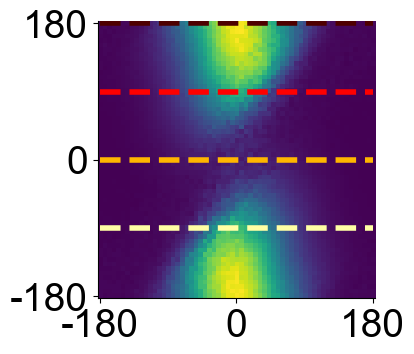

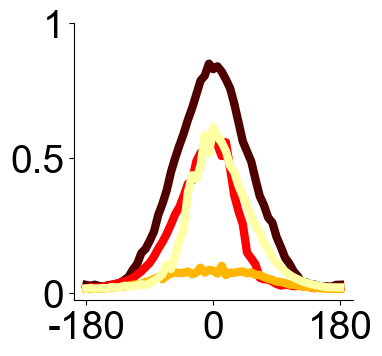

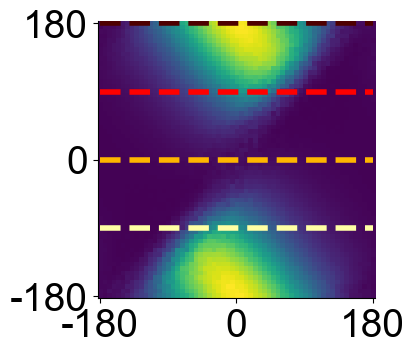

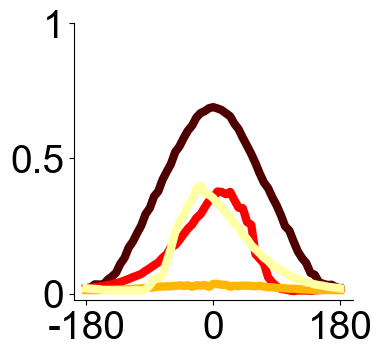

In [12]:
# 1. Setup indices
# "l = meanfire1.shape[0]" -> smeanfire1.shape[0]
l = smeanfire1.shape[0]
deg0 = int(round(l/2))
ixs_r = [0, int(round(l/4)), deg0, int(round(deg0+(l/4)))]

# Colormap
clist = get_colormaps(len(ixs_r))
# 2. Specific Example Plots (Direction)
print("\n--- Plotting Direction Examples ---")
ex_indices = get_example_indices()
ix_chosen = ex_indices['chosen']
plot_direction_tuning_examples(meanfire1, ix_chosen, ixs_r, clist, style)


--- Plotting 5-Subject Overview ---


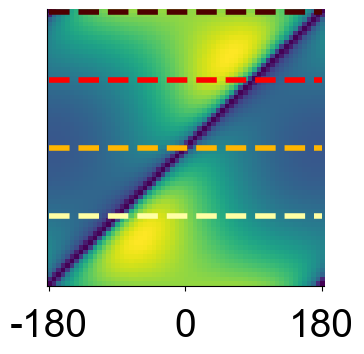

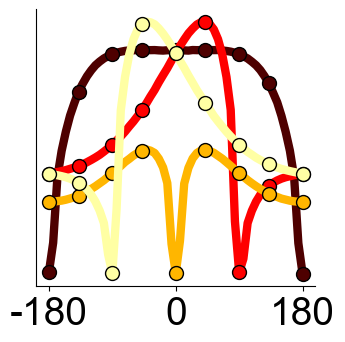

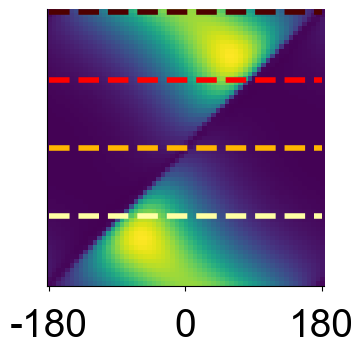

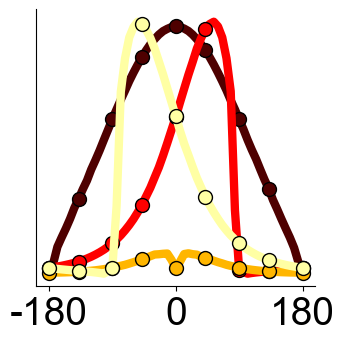

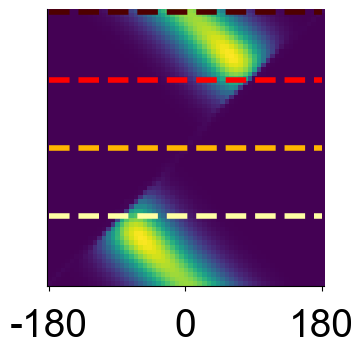

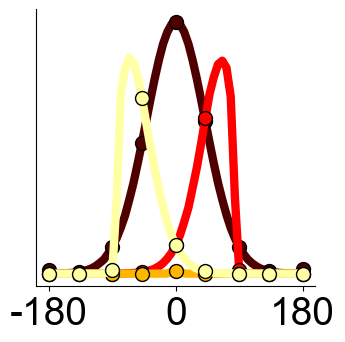

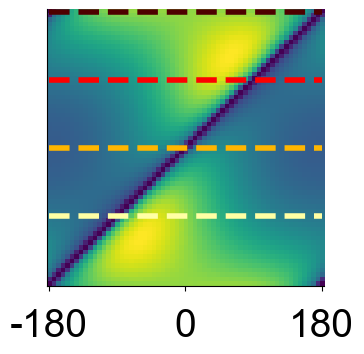

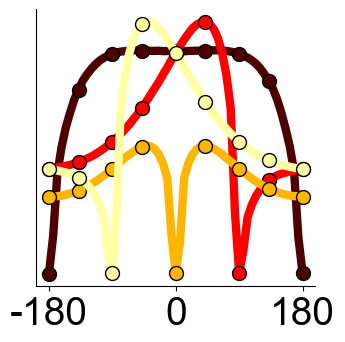

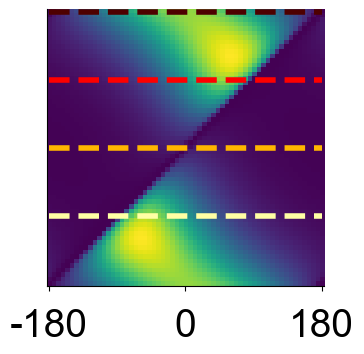

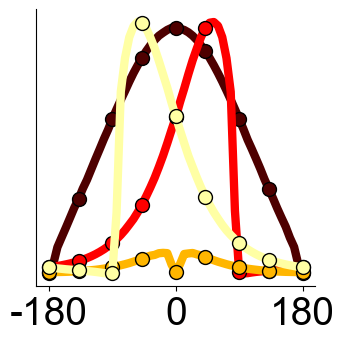

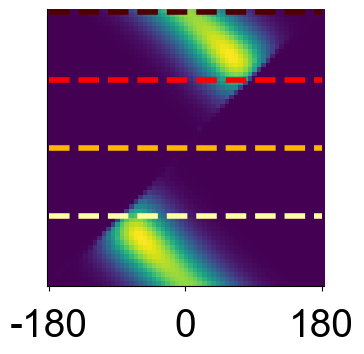

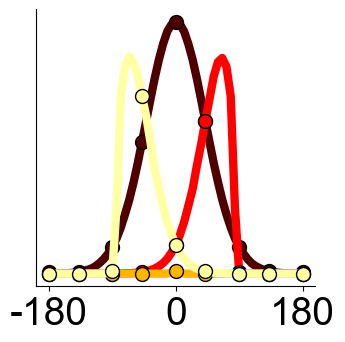

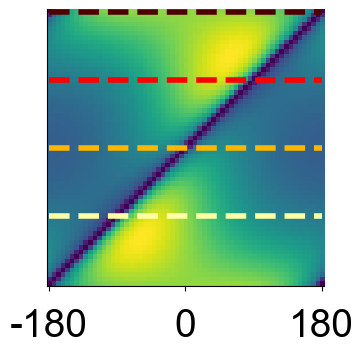

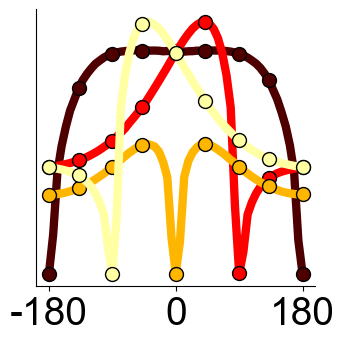

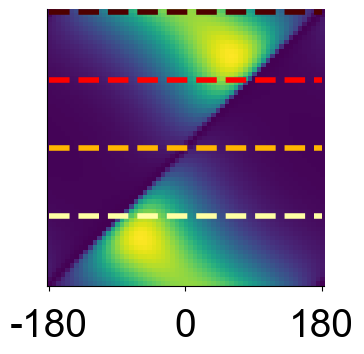

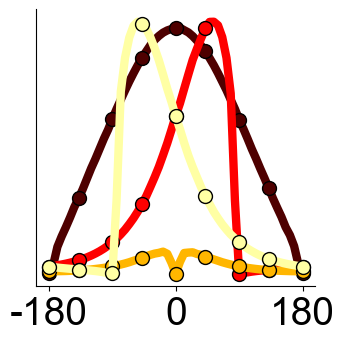

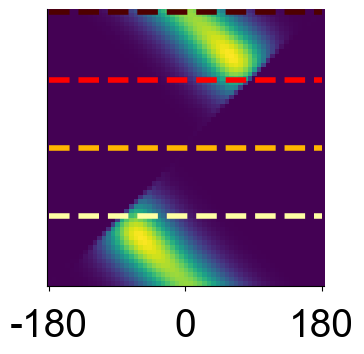

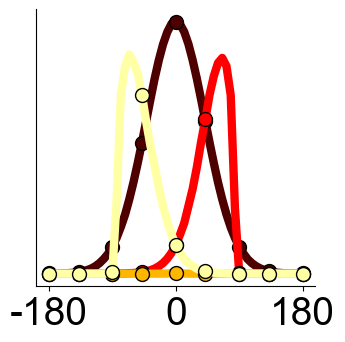

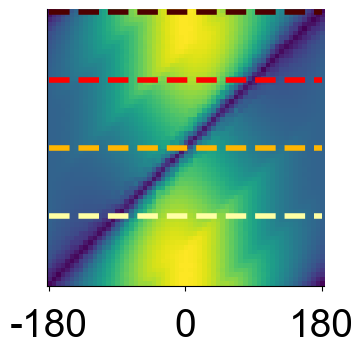

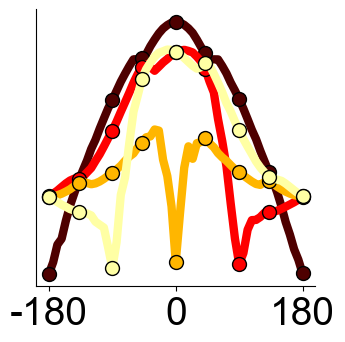

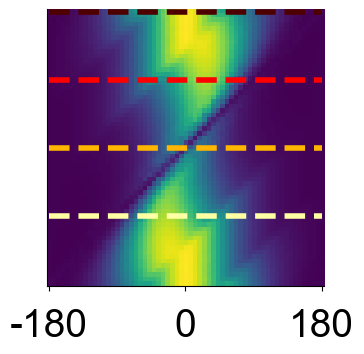

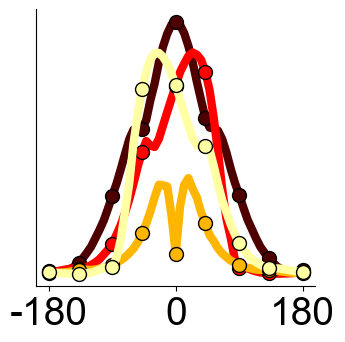

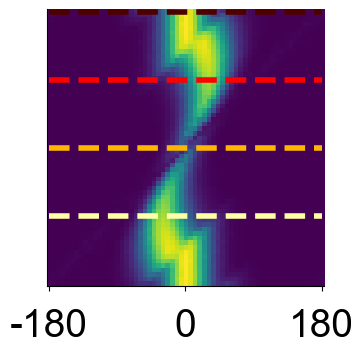

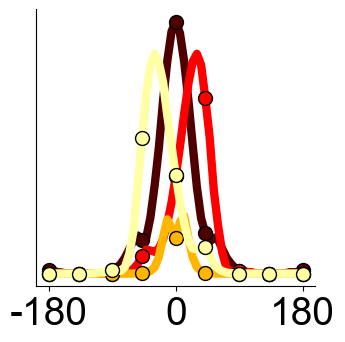

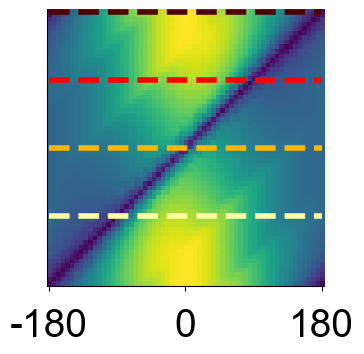

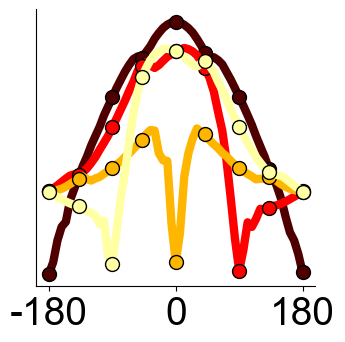

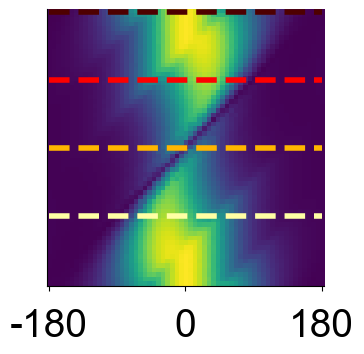

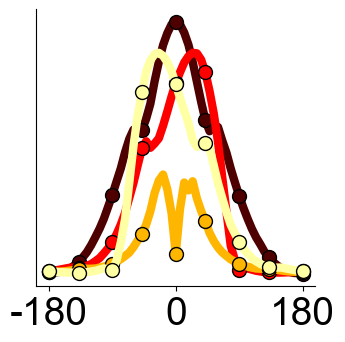

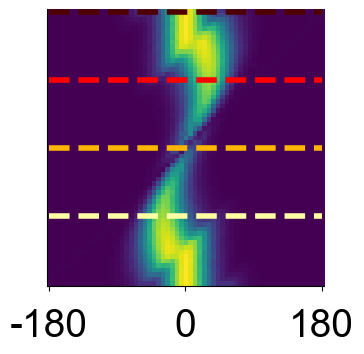

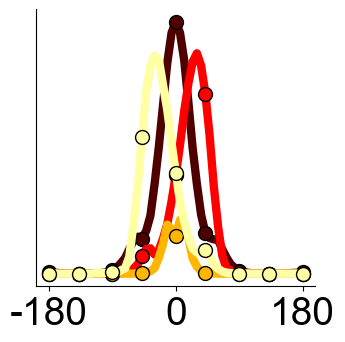

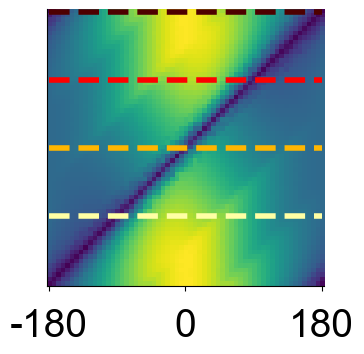

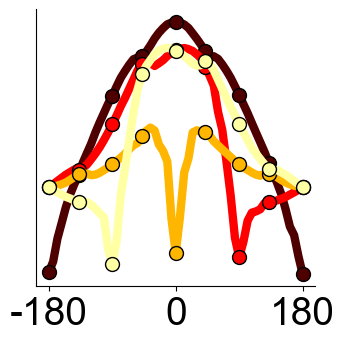

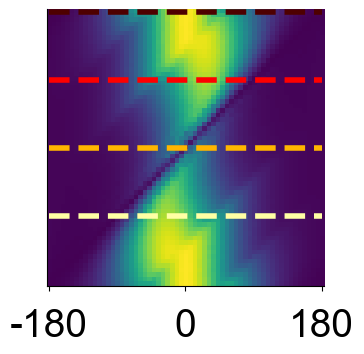

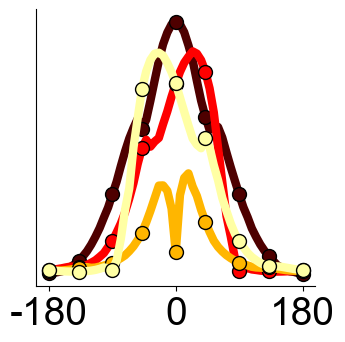

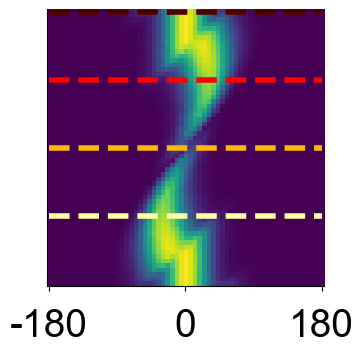

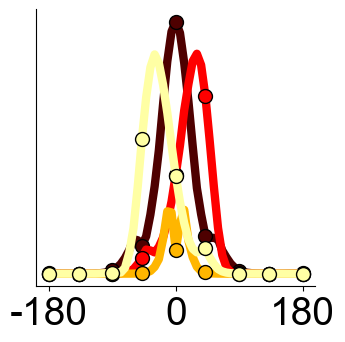

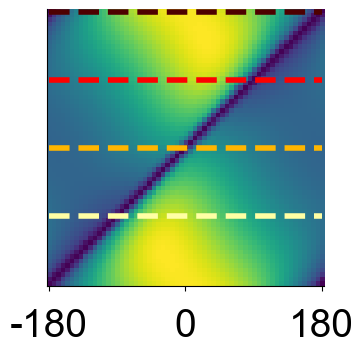

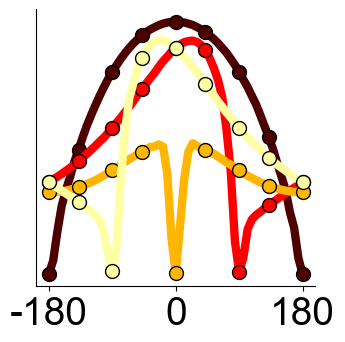

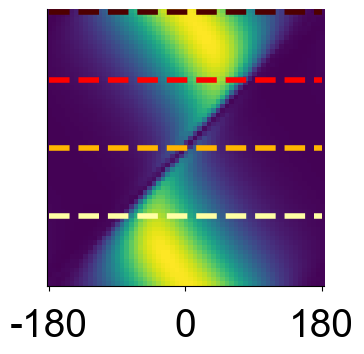

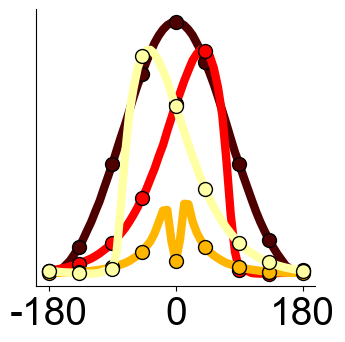

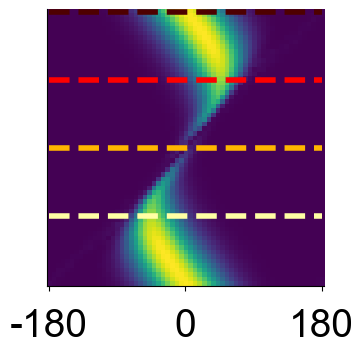

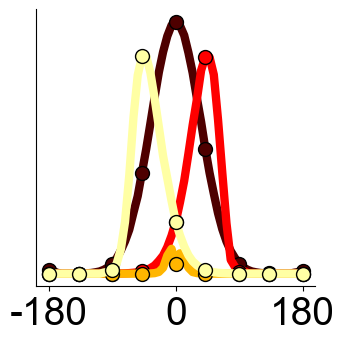

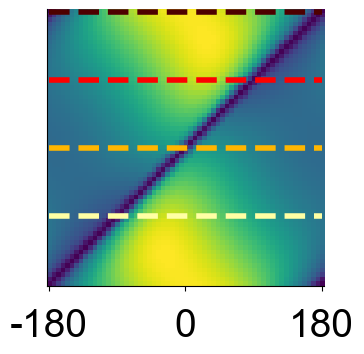

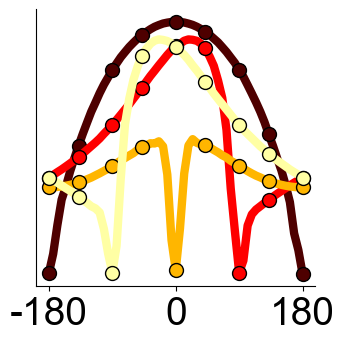

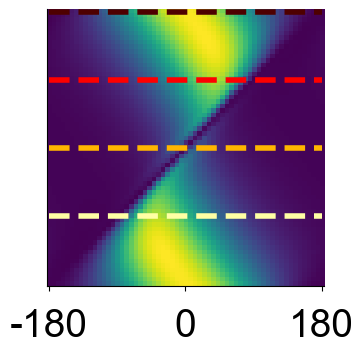

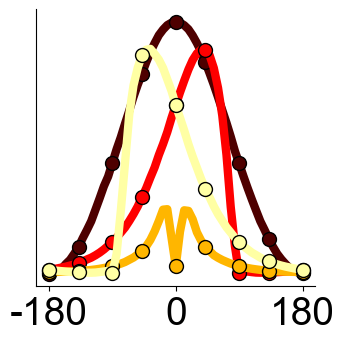

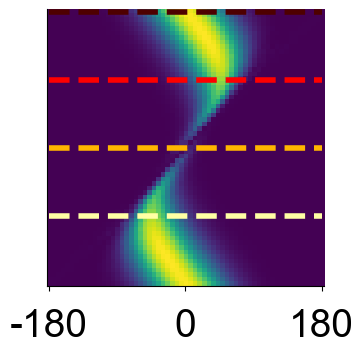

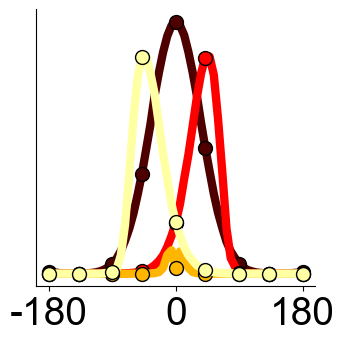

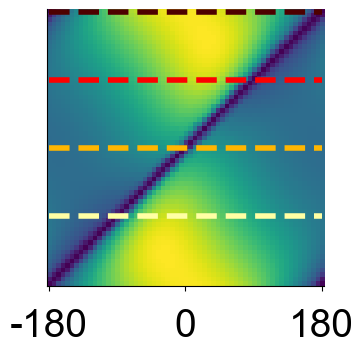

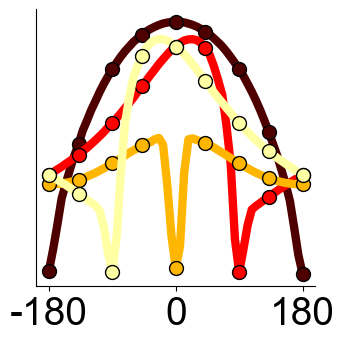

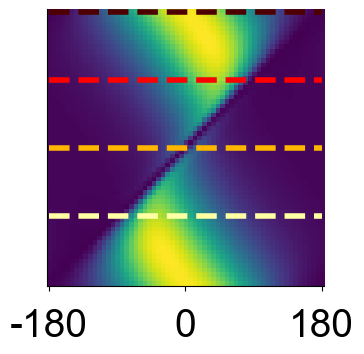

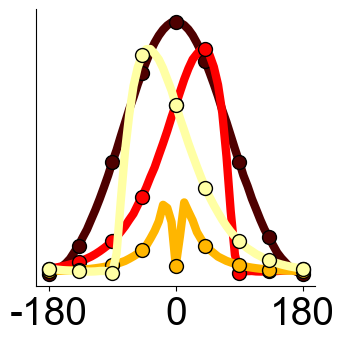

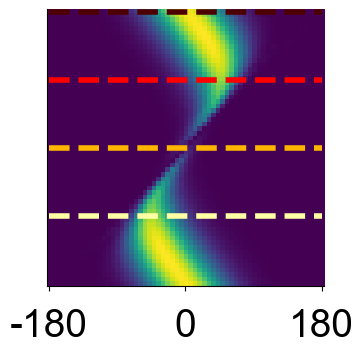

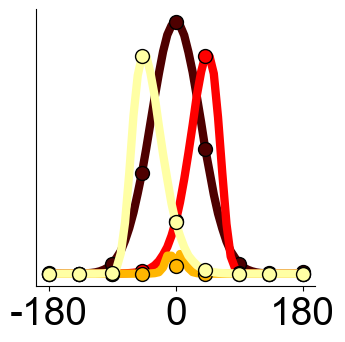

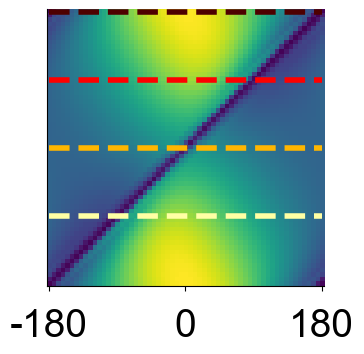

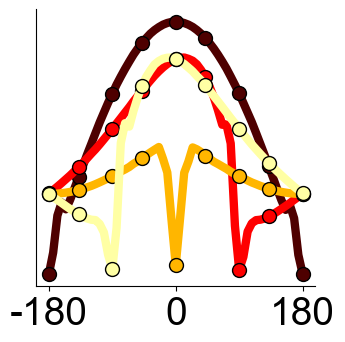

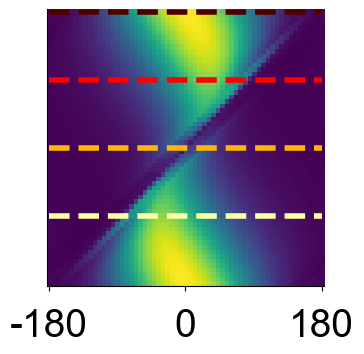

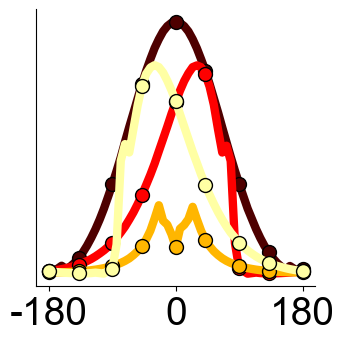

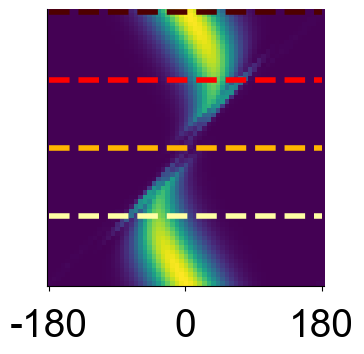

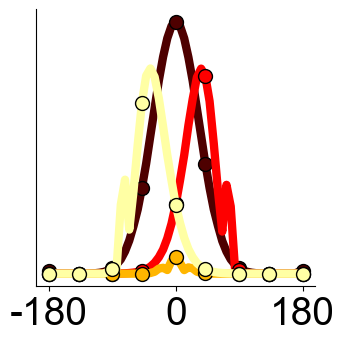

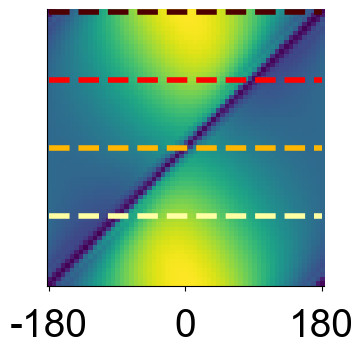

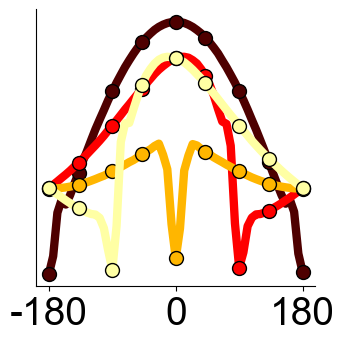

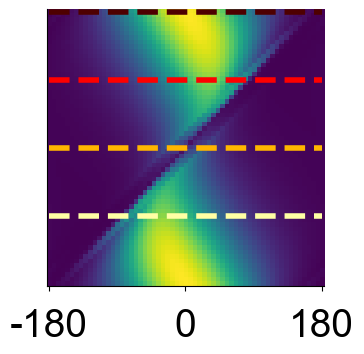

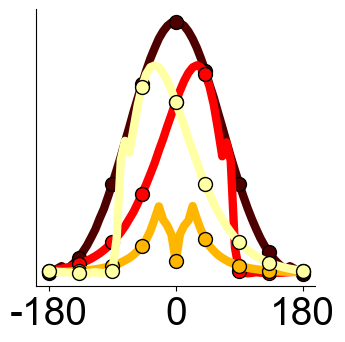

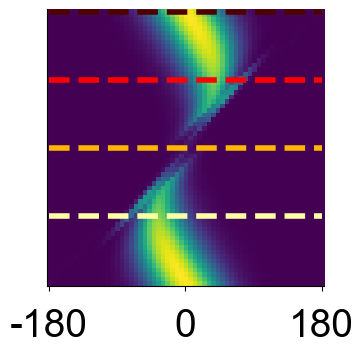

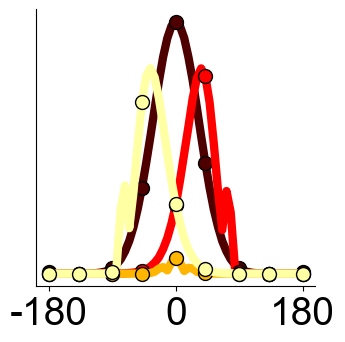

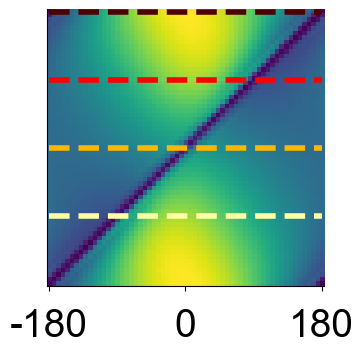

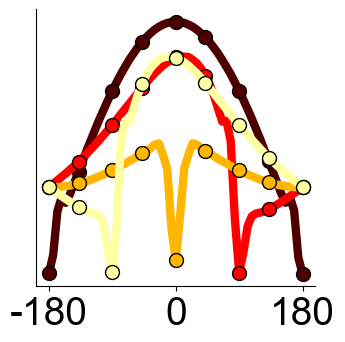

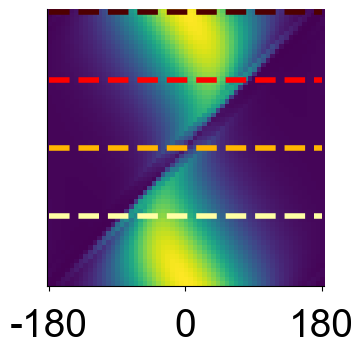

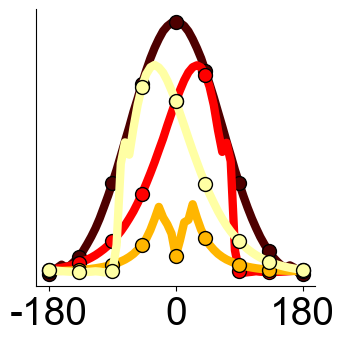

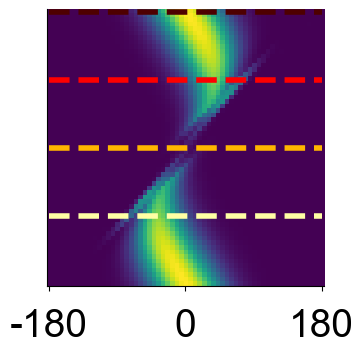

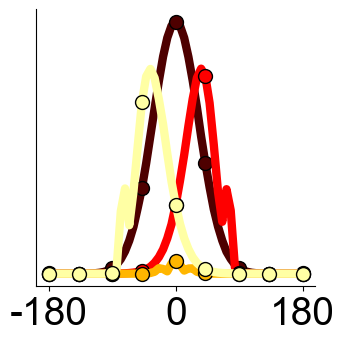

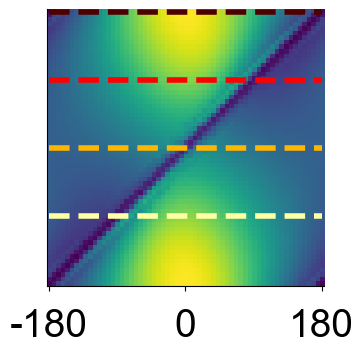

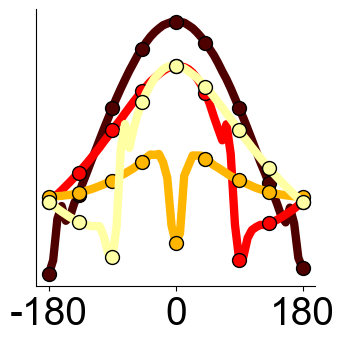

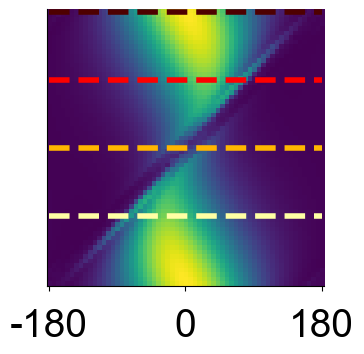

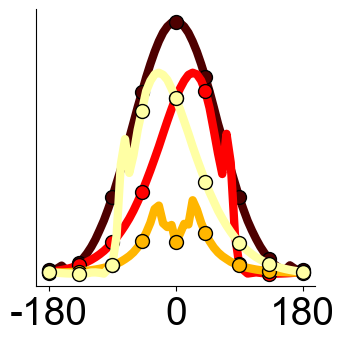

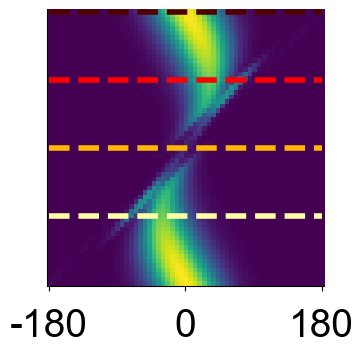

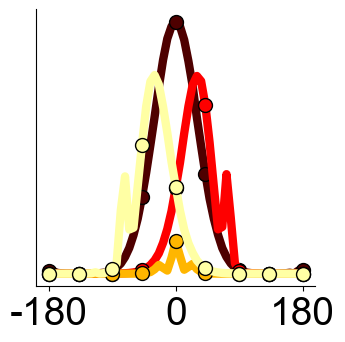

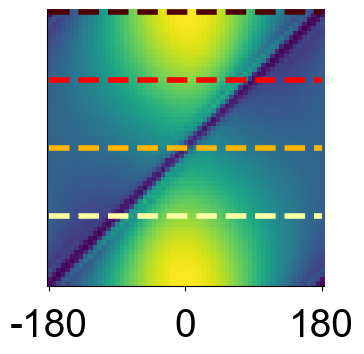

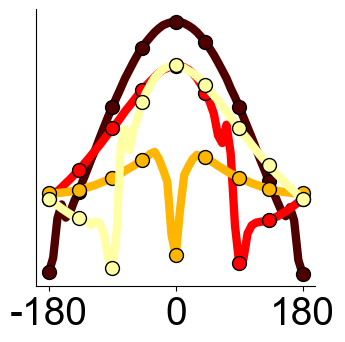

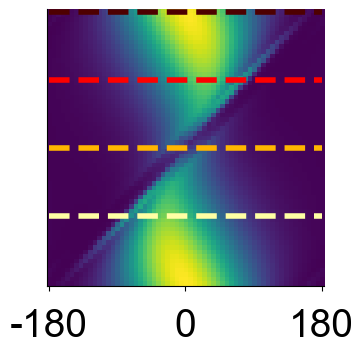

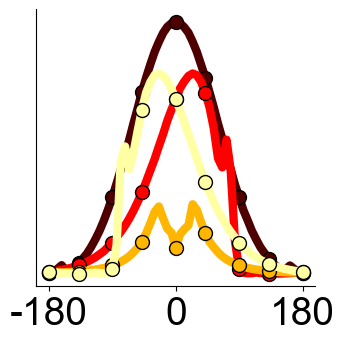

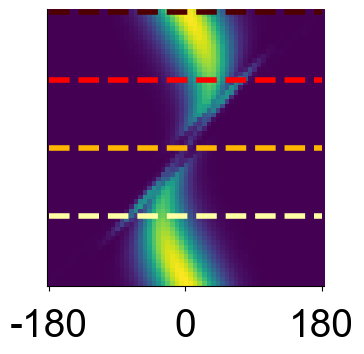

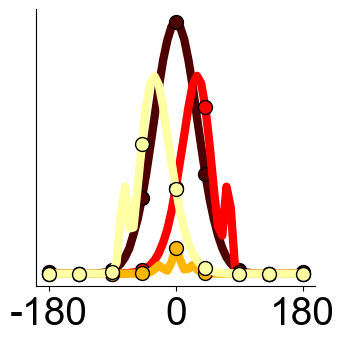

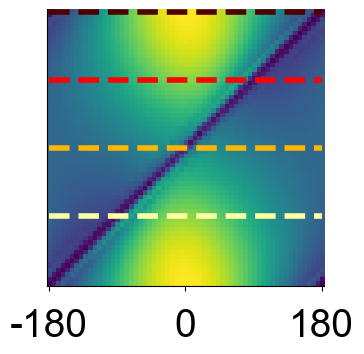

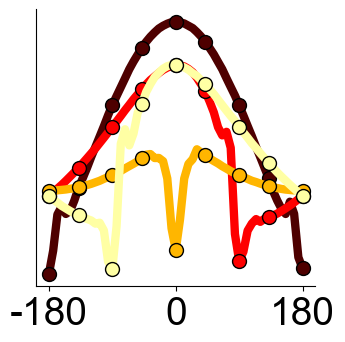

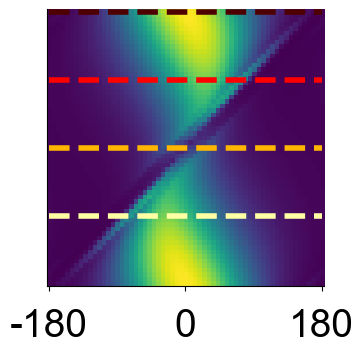

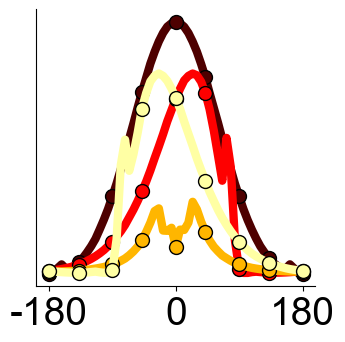

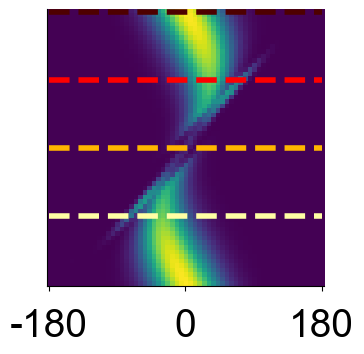

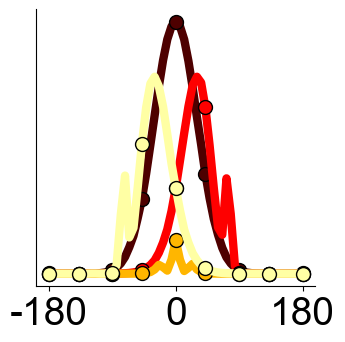

In [15]:

# 3. 5-Subject Overview
print("\n--- Plotting 5-Subject Overview ---")
plot_subject_overview(smeanfire1, ixs_r, clist, style)


--- Shift Analysis (Violin) ---


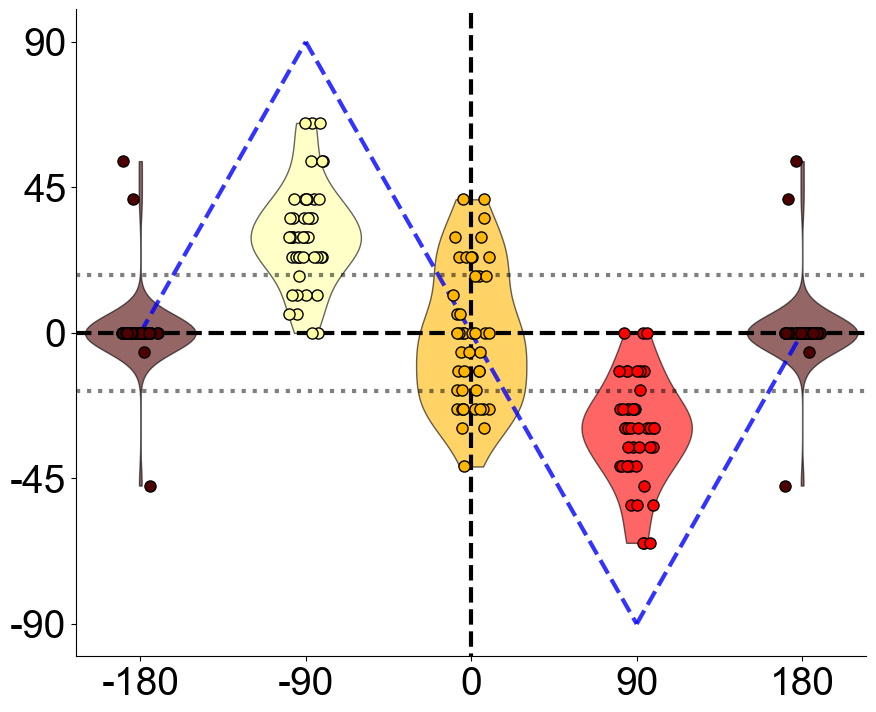

In [19]:
# 4. Shift Analysis
print("\n--- Shift Analysis (Violin) ---")
scale_factor = 360 / smeanfire1.shape[0] # assuming smeanfire0 same shape
shift_s, wix = calculate_shift_s(smeanfire1, ixs_r, deg0, scale_factor)

plot_shift_violin_final(shift_s, ixs_r, clist, style)

In [22]:
# open the file in read mode
file_path = ppath / 'MF_spd_full.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    pmeanfire1 = file['meanfire']
    pmeanfire1 = np.array(pmeanfire1)
    print(pmeanfire1.shape)

(26, 26, 3, 500, 9)


In [23]:
# open the file in read mode
file_path = ppath / 'MF_5subj_spd_full.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    spmeanfire1 = file['meanfire']
    spmeanfire1 = np.array(spmeanfire1)
    print(spmeanfire1.shape)

(26, 26, 3, 5, 9)


In [24]:
# open the file in read mode
file_path = ppath / 'MF_5subj_full.mat'
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    spmeanfire12d = file['meanfire']
    spmeanfire12d = np.array(spmeanfire12d)
    print(spmeanfire12d.shape)

(61, 61, 5, 6, 3, 5, 9)


In [36]:
def plot_speed_tuning_examples(pmeanfire1, ix_chosen, line_w, figS, f_font1):
    """
    Plots specific speed tuning examples.
    """
    tckix = [0,12,24]
    tckvalx = ["0", "3", "28"]
    tckiy = [0,0.5,1]
    
    n_conds = pmeanfire1.shape[1]
    ixs = range(n_conds)
    
    clist = []
    for cname in ["winter", "hot"]:
        c = cm.get_cmap(cname, 100)
        clist.append(ListedColormap(c(np.linspace(0.1, 0.9, n_conds))))
        
    ps = 0.6
    for ix in ix_chosen:
        t1 = pmeanfire1[1:,:,ix[0],ix[1],ix[2]]
        
        _, ax2 = plt.subplots(1, 1, figsize=(figS*ps, figS*ps))
        for i, j in enumerate(ixs):
            ax2.plot(t1[:,j], "-", linewidth=line_w+4, color=clist[0](i))
            
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.grid(False)
        ax2.yaxis.set_ticks(tckiy)
        ax2.yaxis.set_ticklabels(tckiy)
        ax2.xaxis.set_ticks(tckix)
        ax2.xaxis.set_ticklabels(tckvalx)
        
        for labl in (ax2.get_xticklabels()+ax2.get_yticklabels()):
            labl.set_fontname(f_font1["fontname"])
            labl.set_fontsize(f_font1["size"]-2)
        plt.show()

def plot_speed_5subj_grid(spmeanfire1, spmeanfire12d, parula_map, figS, line_w, f_font1):
    """
    Plots the 5x5 grid of speed tuning and the associated curves.
    """
    ix1s = [(0,4), (2,6)]
    ix2s = [(0,6), (2,6)]
    ixs3 = [(3,5), (4,5)]
    IX = [ix1s, ix2s, ixs3, ixs3]
    
    tckix = [0,12,24]
    tckixD = [0,30,60]
    tckvalx = ["0", "3", "28"]
    tckvalD = ["-180","0","180"]
    tckvalD2 = ["180","0","-180"]
    tckiy = [0,0.5,1]
    
    ixr = [[3,7,9,11,17,20],
           [14,16,17,21,23],
           [14,16,17,21,23],
           [14,16,17,21,23],
    ]
    ix1 = 30
    ix2 = 0
    m = 0
    ixS = [[1,4,5,9,12],
        [2,7,10,16,19],
           [13,15,16,20,22],
    ]
    
    clist=[]
    for cname in ["winter", "hot"]:
        c = cm.get_cmap(cname, 100)
        clist.append(ListedColormap(c(np.linspace(0.3, 1, len(ixS[0])))))
        
    ps = 0.6
    
    for ii, iv in enumerate(IX):
        er = 0 if ii == 0 else 1
        for ix in iv:
            # 1. 5x5 Grid Plot
            _, ax = plt.subplots(5, 5, figsize=(figS*1.2, figS*1.2))
            ax = ax.flatten()
            
            p=0
            ci=0
            for s1 in range(5,0,-1):
                for s2 in range(5):
                    ni_val = ix[1]
                    
                    if ni_val in [0,1,2]:
                        ixs_local = ixS[0] 
                    elif ni_val in [3,4,5]:
                        ixs_local = ixS[1]
                    elif ni_val in [6,7,8]:
                        ixs_local = ixS[2]
                    else:
                        ixs_local = ixS[1]

                    t = spmeanfire12d[:,:,s2,s1,er,ix[0],ix[1]]
                    t = np.flip(t.T, axis=0)
                    ax[p].imshow(t, vmin=0, vmax=1, cmap=parula_map)
                    ax[p].plot(ix1, ix2, "o", markersize=12, markeredgecolor='black', markerfacecolor=clist[0](s1-1))
                    ax[p].spines["top"].set_visible(False)
                    ax[p].spines["right"].set_visible(False)
                    ax[p].grid(False)
                    
                    if p % 5 == 0:
                        ax[p].yaxis.set_ticks(tckixD)
                        ax[p].yaxis.set_ticklabels(tckvalD2, **f_font1)
                        if p > 19:
                            ax[p].xaxis.set_ticks(tckixD)
                            ax[p].xaxis.set_ticklabels(tckvalD, rotation=90, **f_font1)
                        else:
                            ax[p].xaxis.set_ticks([])
                    elif p > 19:
                        ax[p].yaxis.set_ticks([])
                        ax[p].xaxis.set_ticks(tckixD)
                        ax[p].xaxis.set_ticklabels(tckvalD, rotation=90, **f_font1)
                    else:
                        ax[p].xaxis.set_ticks([])
                        ax[p].yaxis.set_ticks([])
                        
                    for labl in (ax[p].get_xticklabels() + ax[p].get_yticklabels()):
                        labl.set_fontname(f_font1["fontname"])
                        labl.set_fontsize(f_font1["size"]-10)
                    p+=1
                ci+=1
            plt.tight_layout()
            plt.show()

            # 2. Tuning Curve Plot
            t1 = spmeanfire1[1:,:,er,ix[0],ix[1]]
            
            _, ax2 = plt.subplots(1, 1, figsize=(figS*ps, figS*ps))
            for i,j in enumerate(ixs_local):
                ax2.plot(t1[:,j], "-", linewidth=line_w+4, color=clist[0](i))
                if m < len(ixr):
                     if j < t1.shape[1]:
                        ax2.plot(ixr[m], t1[ixr[m],j], "o", markersize=10, color=clist[0](i), markeredgecolor="k")
            
            ax2.spines["top"].set_visible(False)
            ax2.spines["right"].set_visible(False)
            ax2.grid(False)
            ax2.yaxis.set_ticks(tckiy)
            ax2.yaxis.set_ticklabels([" "," "," "])
            ax2.xaxis.set_ticks(tckix)
            ax2.xaxis.set_ticklabels(tckvalx)
            
            for labl in (ax2.get_xticklabels()+ax2.get_yticklabels()):
                labl.set_fontname(f_font1["fontname"])
                labl.set_fontsize(f_font1["size"]-2)
            ax2.tick_params(axis='x', which='major', pad=12)
            plt.show()
            
            m+=1
            
    # Extra Loop for p meanfire examples
    for pi in range(spmeanfire1.shape[3]):
        for ni in range(spmeanfire1.shape[4]):
            t1 = spmeanfire1[1:,:,1,pi,ni]
            local_ixs = [0,7,14,21] 
            local_ixr = [0,3,6,9,12,15,18,21,24]
            
            _, ax2 = plt.subplots(1, 1, figsize=(figS*ps, figS*ps))
            for i,j in enumerate(local_ixs):
                ax2.plot(t1[:,j], "-", linewidth=line_w+4, color=clist[0](i))
                ax2.plot(local_ixr, t1[local_ixr,j], "o", markersize=10, color=clist[0](i), markeredgecolor="k")
            
            ax2.spines["top"].set_visible(False)
            ax2.spines["right"].set_visible(False)
            ax2.grid(False)
            ax2.yaxis.set_ticks(tckiy)
            ax2.yaxis.set_ticklabels([" "," "," "])
            ax2.xaxis.set_ticks(tckix)
            ax2.xaxis.set_ticklabels(tckvalx)
            for labl in (ax2.get_xticklabels()+ax2.get_yticklabels()):
               labl.set_fontname(f_font1["fontname"])
               labl.set_fontsize(f_font1["size"]-2)
            ax2.tick_params(axis='x', which='major', pad=12)
            plt.show()

def calculate_speed_shifts(pmeanfire1, spmeanfire1, vector_subtract):
    """
    Calculates speed shifts.
    """
    direction1 = 0
    direction2 = 180
    
    speed_t = np.hstack([0, 0.01, 0.05, 0.1, 0.3, 0.6, np.logspace(0, 1.46, 20)])
    relSpd = np.zeros((26,26))
    
    for i, s1 in enumerate(speed_t):
        for j, s2 in enumerate(speed_t):
            _, result_speed = vector_subtract(direction1, s1, direction2, s2)
            relSpd[i,j] = result_speed
            
    # 2. Calculate shifts for single subject
    ixs = [[1,4,5,9,12],
           [2,7,10,16,19],
           [13,15,16,20,22]]
           
    n1 = pmeanfire1.shape[2] * pmeanfire1.shape[3] * pmeanfire1.shape[4]
    shift = np.zeros((n1, len(ixs[0]))) + np.nan
    
    i = 0
    for ei in range(pmeanfire1.shape[2]):
        for pi in range(pmeanfire1.shape[3]):
            for ni in range(pmeanfire1.shape[4]):
                t1 = pmeanfire1[1:,:,ei,pi,ni]
                if ni in [0,1,2]:
                    pref = speed_t[5]
                    t = t1[:, ixs[0]]
                elif ni in [3,4,5]:
                    pref = speed_t[10]
                    t = t1[:, ixs[1]]
                elif ni in [6,7,8]:
                    pref = speed_t[16]
                    t = t1[:, ixs[2]]
                else:
                    t = t1[:, ixs[1]]
                    pref = speed_t[10]
                    
                maxix = np.argmax(t, axis=0)
                maxval = np.max(t, axis=0)
                
                if not (maxval < 0.1).all():
                    shift[i,:] = [speed_t[xix] - pref for xix in maxix]
                i += 1
                
    # 3. Calculate shifts for 5-subject
    n2 = spmeanfire1.shape[3] * spmeanfire1.shape[4]
    shift_s = np.zeros((n2, len(ixs[0]))) + np.nan
    i = 0
    
    for pi in range(spmeanfire1.shape[3]):
        for ni in range(spmeanfire1.shape[4]):
            t1 = spmeanfire1[1:,:,0,pi,ni]
            if ni in [0,1,2]:
                pref = speed_t[5]
                t = t1[:, ixs[0]]
            elif ni in [3,4,5]:
                pref = speed_t[10]
                t = t1[:, ixs[1]]
            elif ni in [6,7,8]:
                pref = speed_t[16]
                t = t1[:, ixs[2]]
            else:
                 t = t1[:, ixs[1]]
                 pref = speed_t[10]
                 
            maxix = np.argmax(t, axis=0)
            shift_s[i,:] = [speed_t[xix] - pref for xix in maxix]
            i += 1
            
    return shift, shift_s, relSpd, speed_t, ixs

def plot_speed_shift_summary(shift_s, relSpd, speed_t, ixs_groups, figS, line_w, f_font1, sp):
    """
    Plots the final violin + spline summary for speed shifts.
    """
    try:
        from scipy.interpolate import UnivariateSpline
    except ImportError:
        print("Scipy not found. Skipping spline.")
        return

    clist = []
    for cname in ["winter", "hot"]:
        c = cm.get_cmap(cname, 100)
        clist.append(ListedColormap(c(np.linspace(0.3, 1, 5))))

    ixs_plot = [-2, -1, 0, 1, 2]
    
    s = []
    for k in range(5):
        s.append(shift_s[np.invert(np.isnan(shift_s[:,k])), k])
        
    half_range = 0.5
    colors = [clist[0](i) for i in range(len(ixs_plot))]
    colors.append(clist[0](0))
    
    _, ax = plt.subplots(1, 1, figsize=(figS*1.7, figS*1.4))
    
    parts = ax.violinplot(s, ixs_plot, showmeans=False, showmedians=False, showextrema=False, widths=half_range)
    
    for pi, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[pi])
        pc.set_edgecolor("k")
        pc.set_alpha(0.6)
        
    limS = 2.5
    ax.plot((0, 0), (-20, 24), "k--", linewidth=line_w+1)
    ax.plot((-limS, limS), (0, 0), "k--", linewidth=line_w+1)
    M = 5
    ax.plot((-limS, limS), (M, M), "k:", linewidth=line_w+1, alpha=0.5)
    ax.plot((-limS, limS), (-M, -M), "k:", linewidth=line_w+1, alpha=0.5)
    
    relR1 = np.hstack((0, 0, 0, -(relSpd[16, 0:17] - speed_t[16])))
    x = np.linspace(-limS, 0, len(relR1))
    x_smooth = np.linspace(min(x), max(x), 1000)
    smoothing_factor = 0.2
    
    try:
        spline = UnivariateSpline(x, relR1, s=smoothing_factor)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, "b--", linewidth=line_w+1, alpha=0.8)
        ax.plot([0, 2.5], [-speed_t[16], -speed_t[16]], "b--", linewidth=line_w+1, alpha=0.8)
    except Exception as e:
        print(f"Spline failed: {e}")
        
    n2 = shift_s.shape[0]
    half_range_scatter = 0.2
    for i, j in enumerate(ixs_plot):
         ax.plot(np.random.uniform(low=j-half_range_scatter, high=j+half_range_scatter, size=n2), 
                 shift_s[:,i], "o", color=clist[0](i), markersize=8, markeredgecolor="k")
                 
    tickiy = [-10,-5,0,5,10]
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    
    ax.yaxis.set_ticks(tickiy)
    ax.yaxis.set_ticklabels(tickiy)
    ax.xaxis.set_ticks(ixs_plot)
    ax.xaxis.set_ticklabels(["-1/2SD","-1/4SD","0","1SD","2SD"])
    
    for labl in (ax.get_xticklabels()+ax.get_yticklabels()):
        labl.set_fontname(f_font1["fontname"])
        labl.set_fontsize(f_font1["size"]-2)
        
    ax.set_xlim(-limS, limS)
    ax.set_ylim(-11, 11)
    
    plt.savefig(sp + 'spdShifts.pdf')
    plt.show()

# Speed analysis


--- Plotting Speed Examples ---


/var/folders/7v/b8fs48v95fxb7gdt_3bqj7q00000gp/T/ipykernel_53730/2900569213.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = cm.get_cmap(cname, 100)


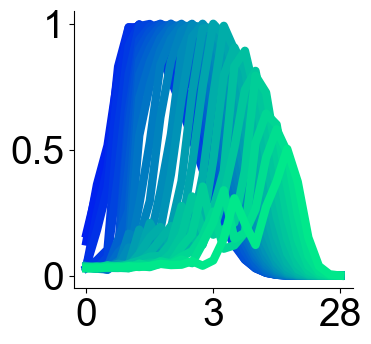

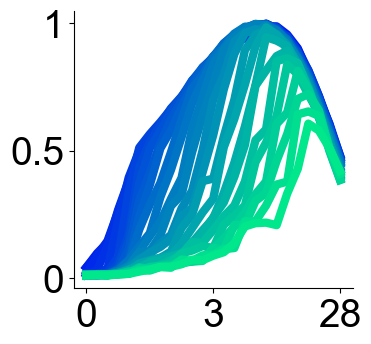

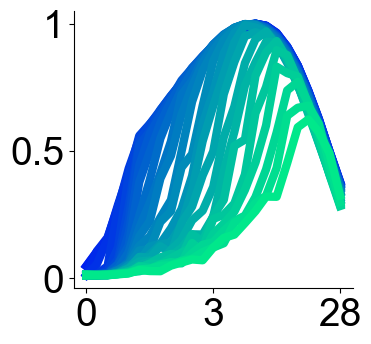

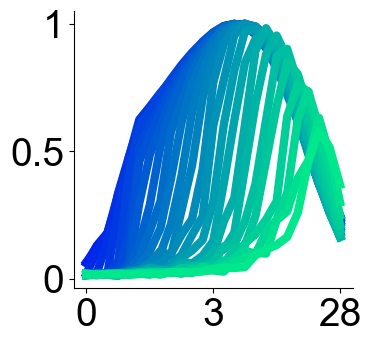

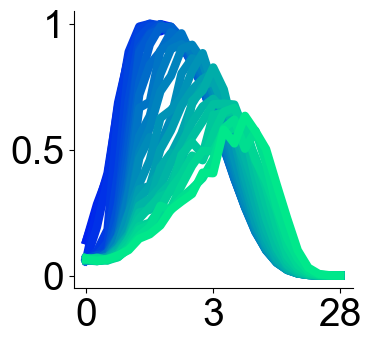

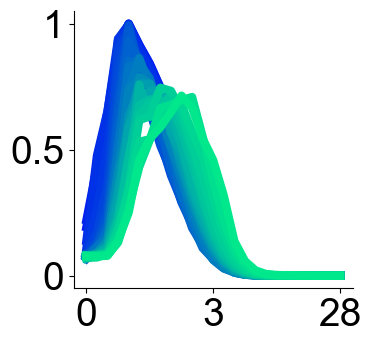

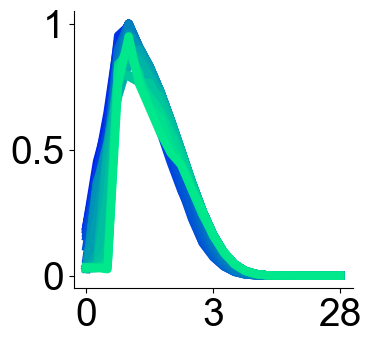

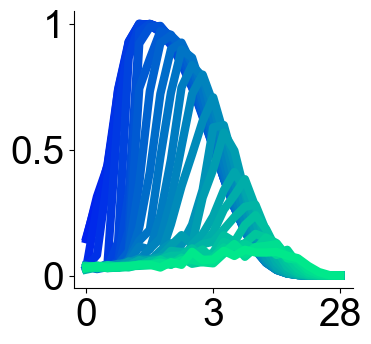

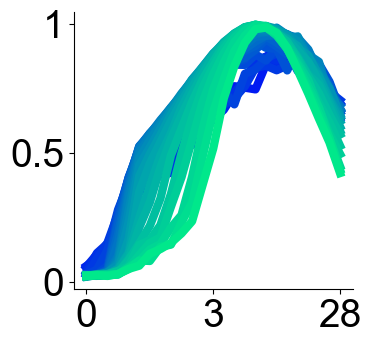

In [37]:
# Speed Examples
print("\n--- Plotting Speed Examples ---")
ix_chosen_speed = [
    (1, 23, 1), (1, 279, 7), (2, 260, 7),
    (1, 423, 4), (1, 250, 1), (2, 290, 1),
    (1, 383, 1), (1, 355, 1), (1, 291, 4)
]
plot_speed_tuning_examples(pmeanfire1, ix_chosen_speed, line_w, figS, f_font1)


--- Speed 5-Subject Grid ---


/var/folders/7v/b8fs48v95fxb7gdt_3bqj7q00000gp/T/ipykernel_53730/2900569213.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = cm.get_cmap(cname, 100)


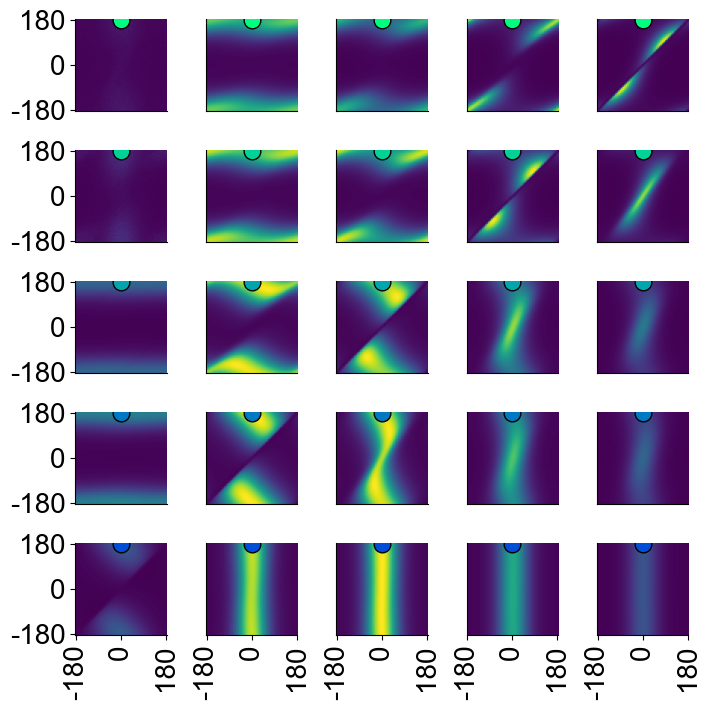

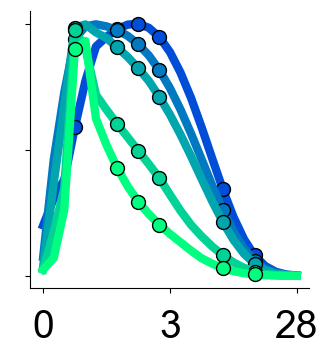

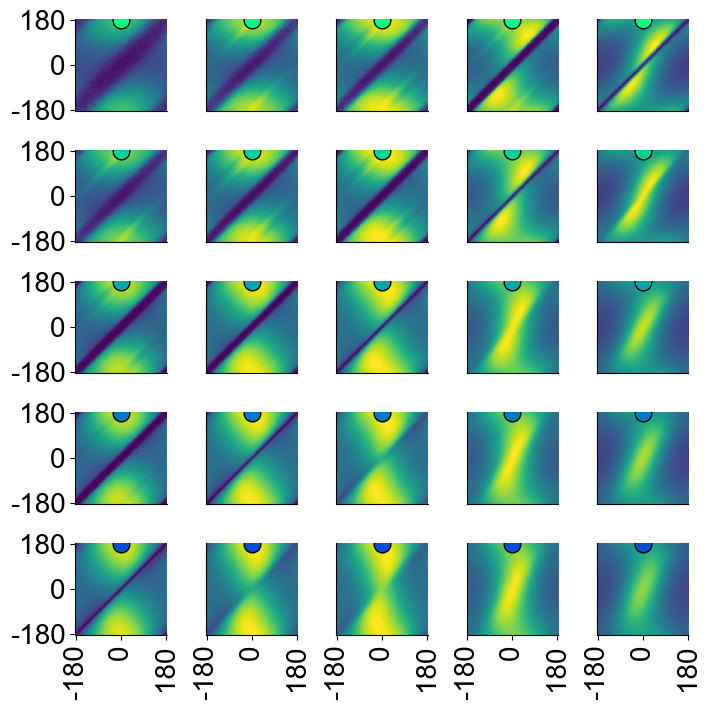

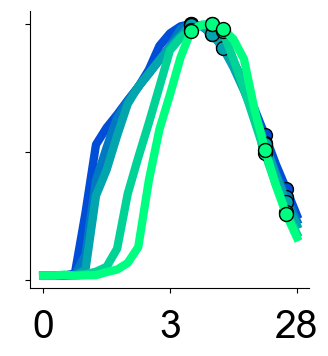

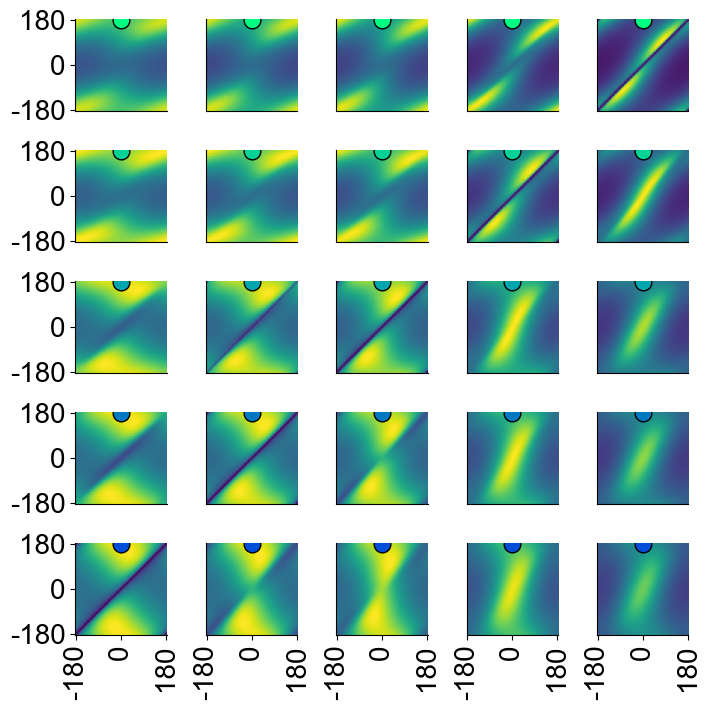

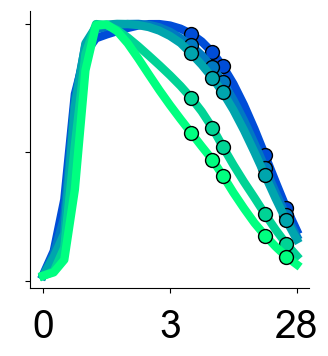

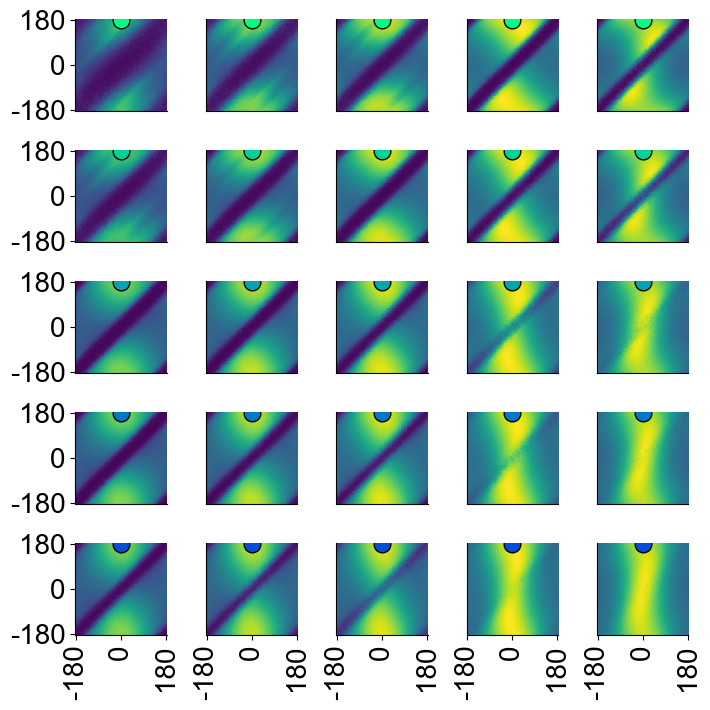

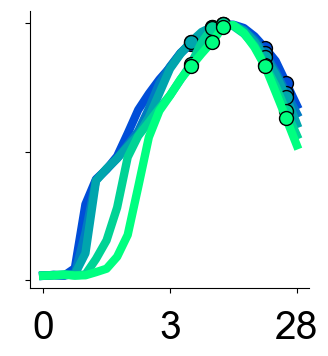

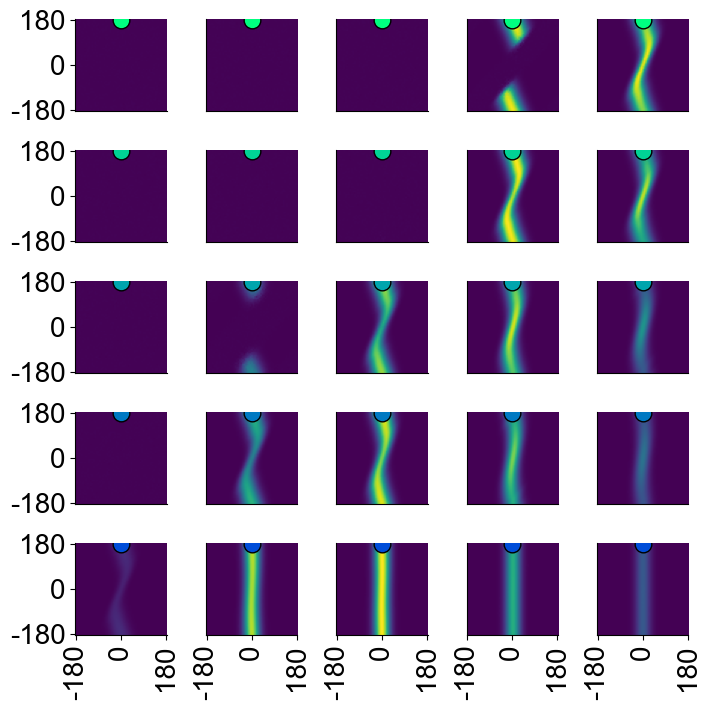

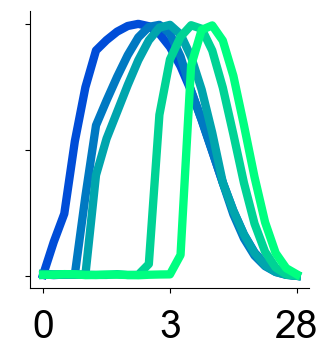

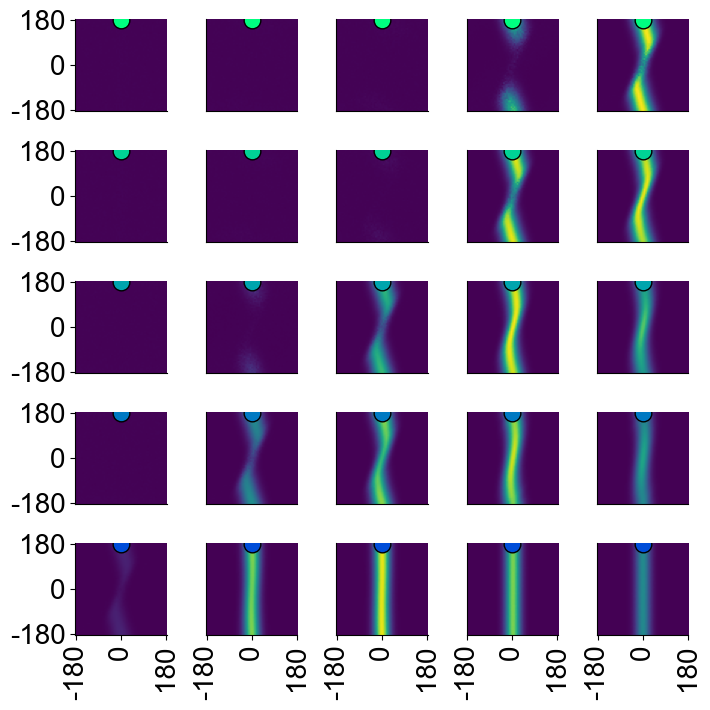

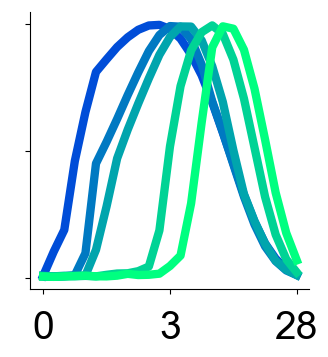

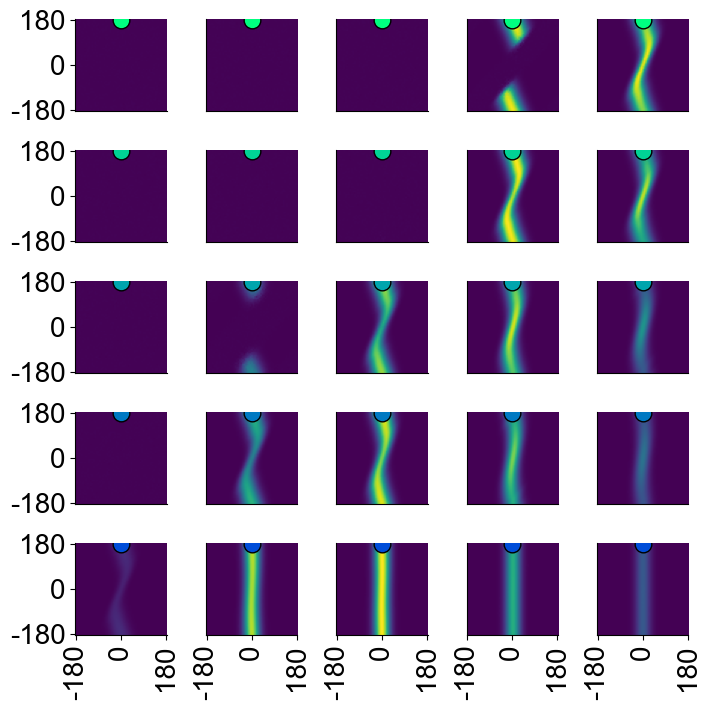

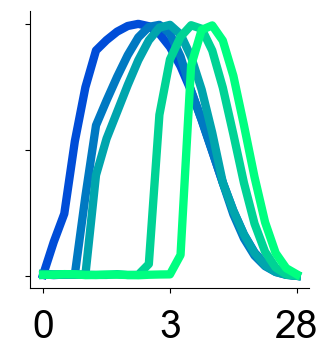

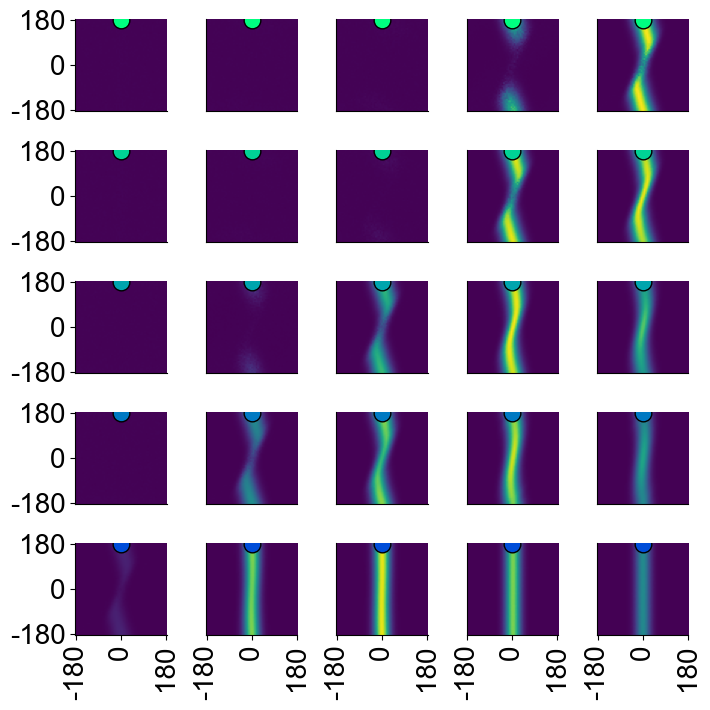

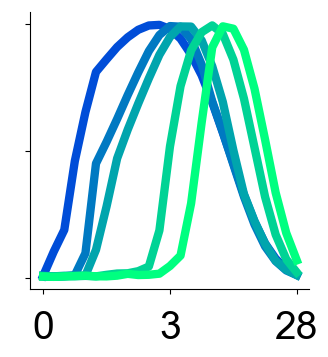

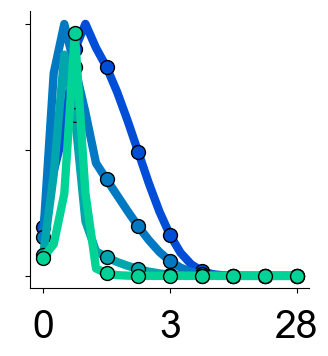

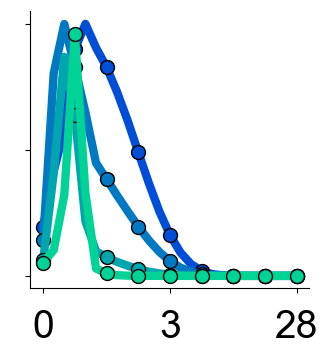

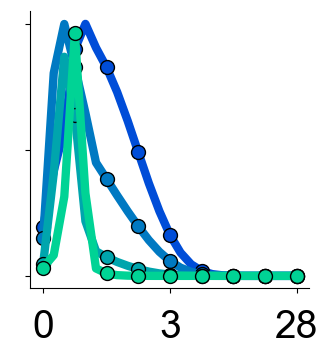

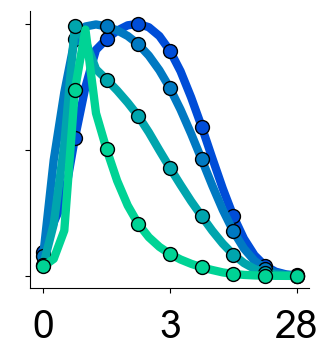

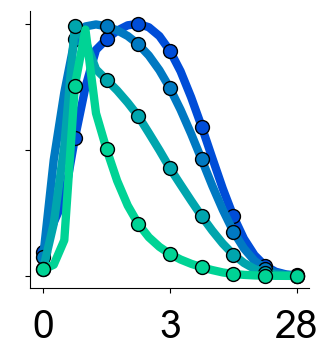

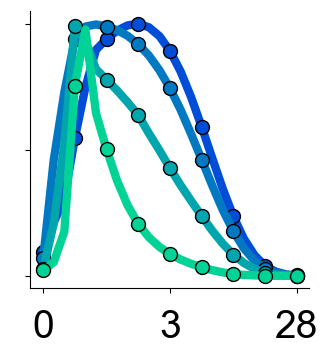

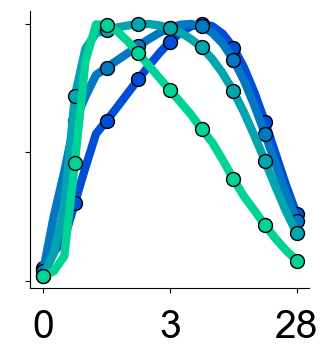

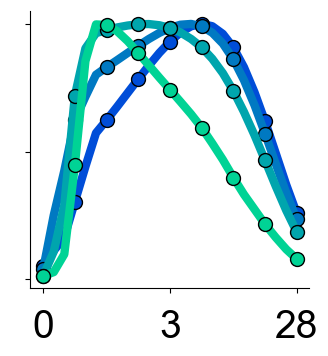

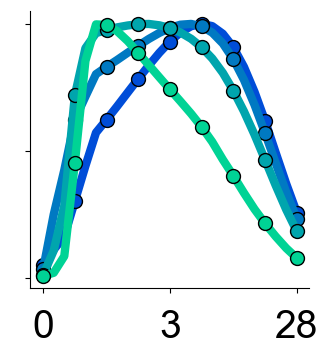

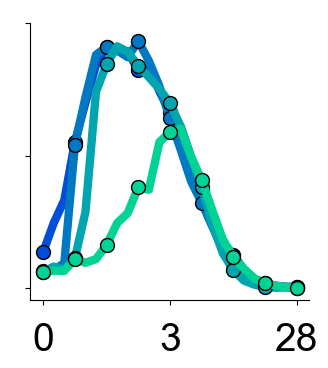

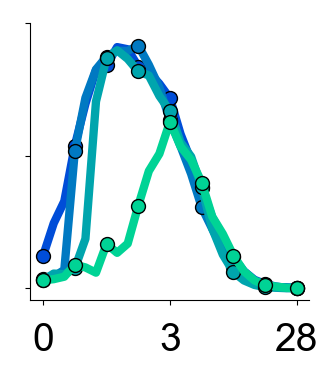

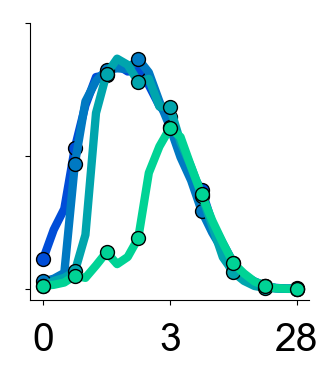

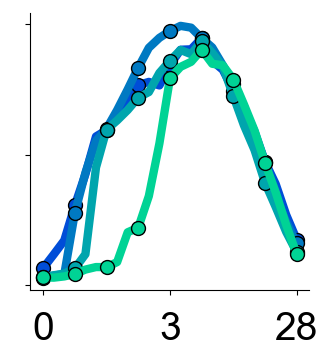

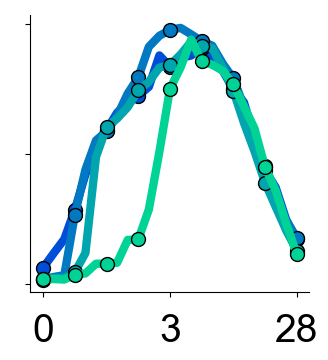

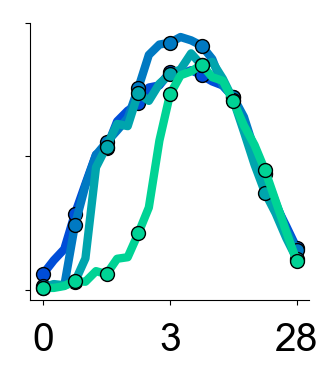

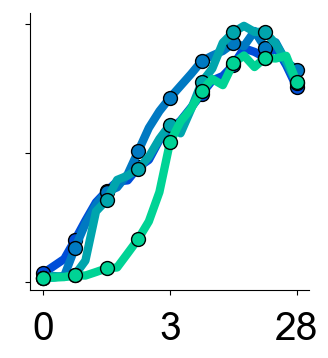

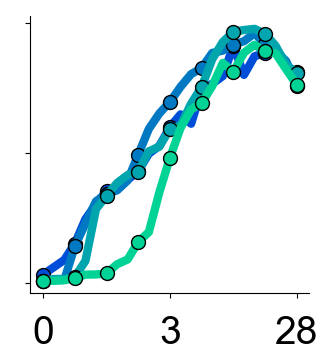

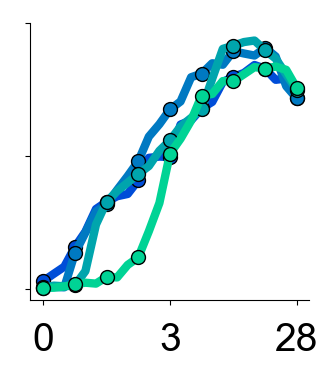

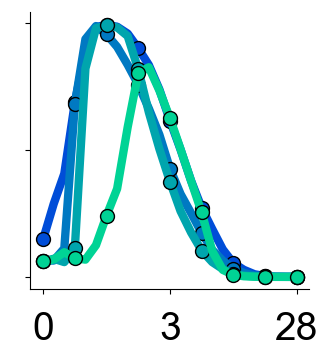

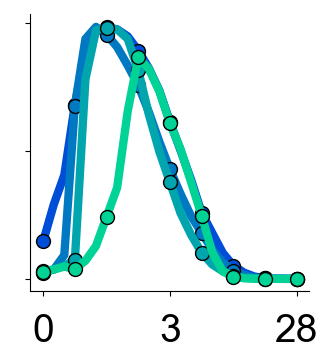

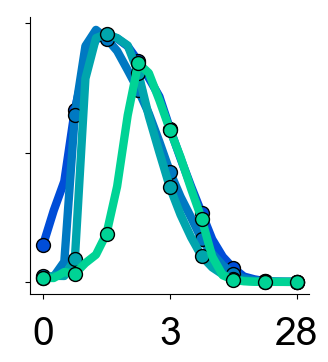

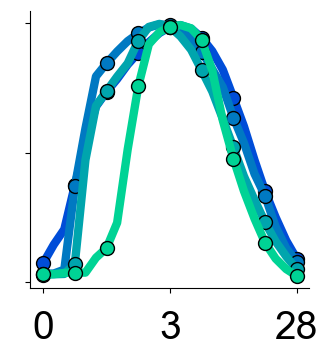

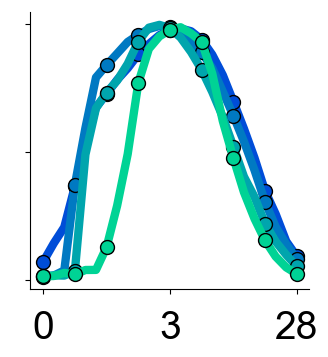

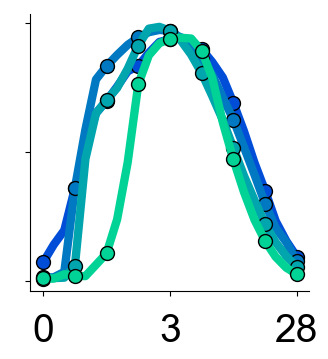

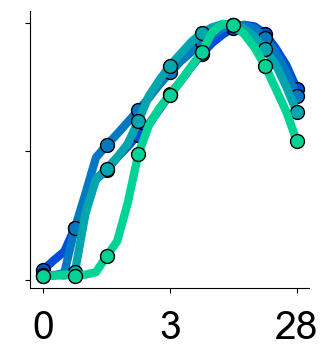

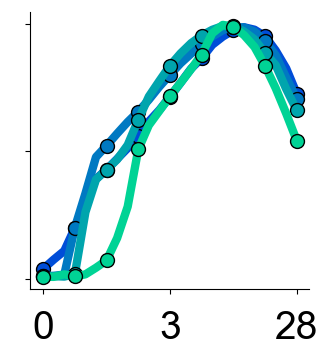

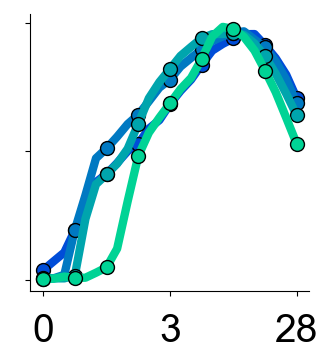

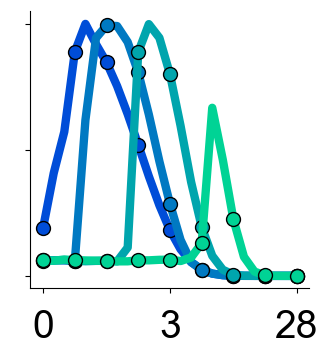

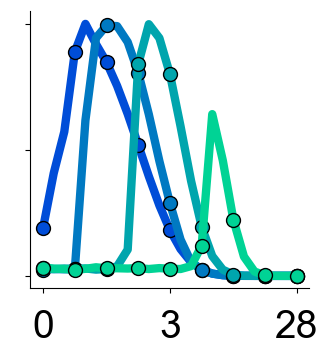

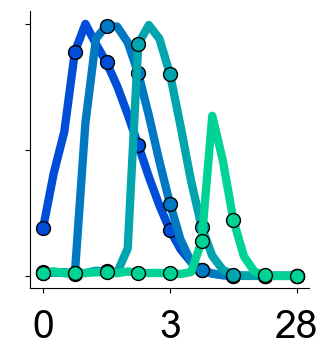

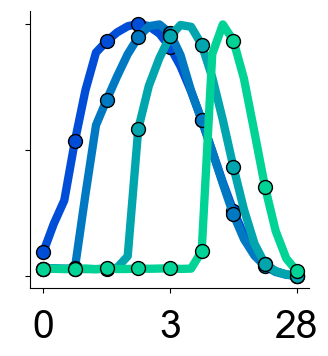

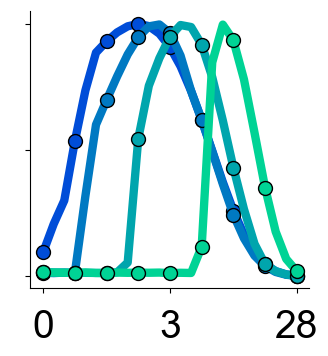

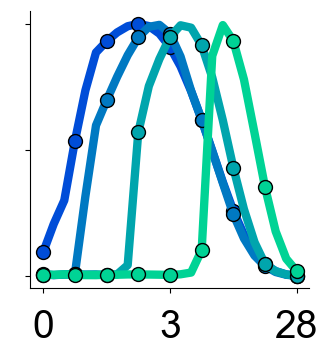

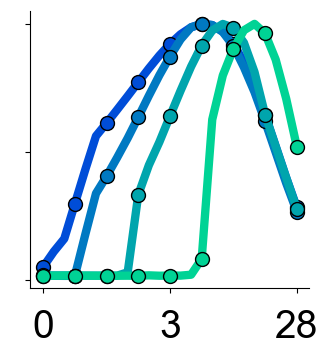

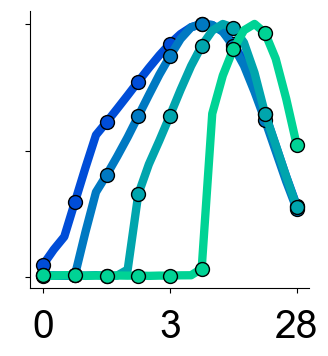

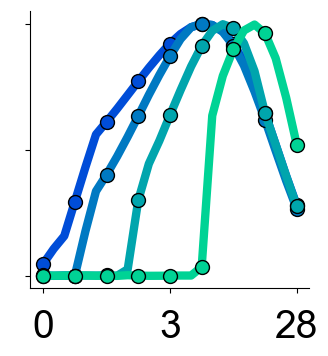

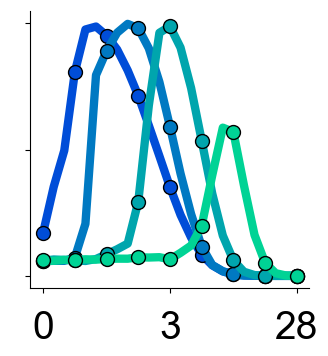

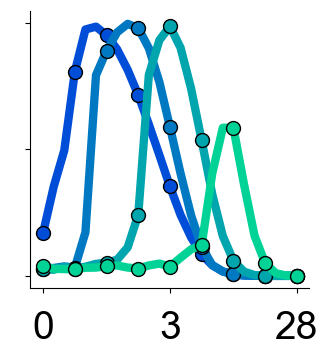

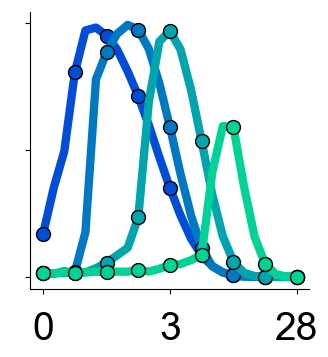

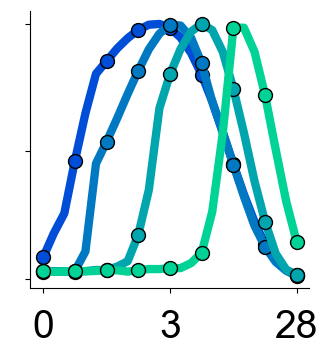

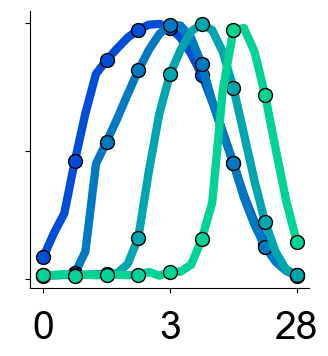

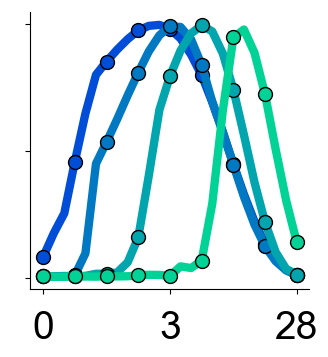

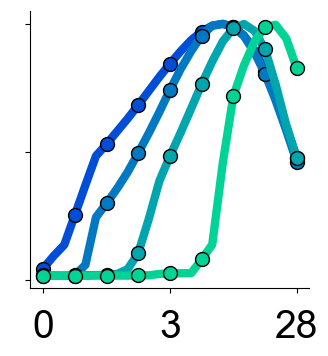

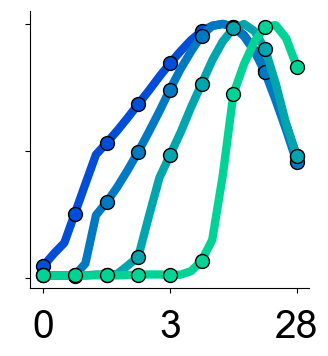

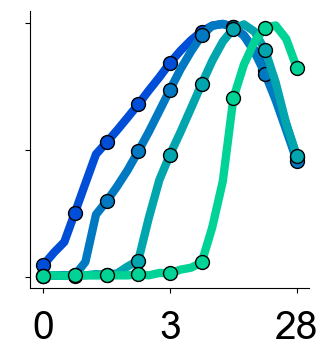

In [38]:
# Speed 5-Subject Grid
print("\n--- Speed 5-Subject Grid ---")
plot_speed_5subj_grid(spmeanfire1, spmeanfire12d, parula_map, figS, line_w, f_font1)


--- Speed Shift Analysis ---


/var/folders/7v/b8fs48v95fxb7gdt_3bqj7q00000gp/T/ipykernel_53730/2900569213.py:266: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = cm.get_cmap(cname, 100)


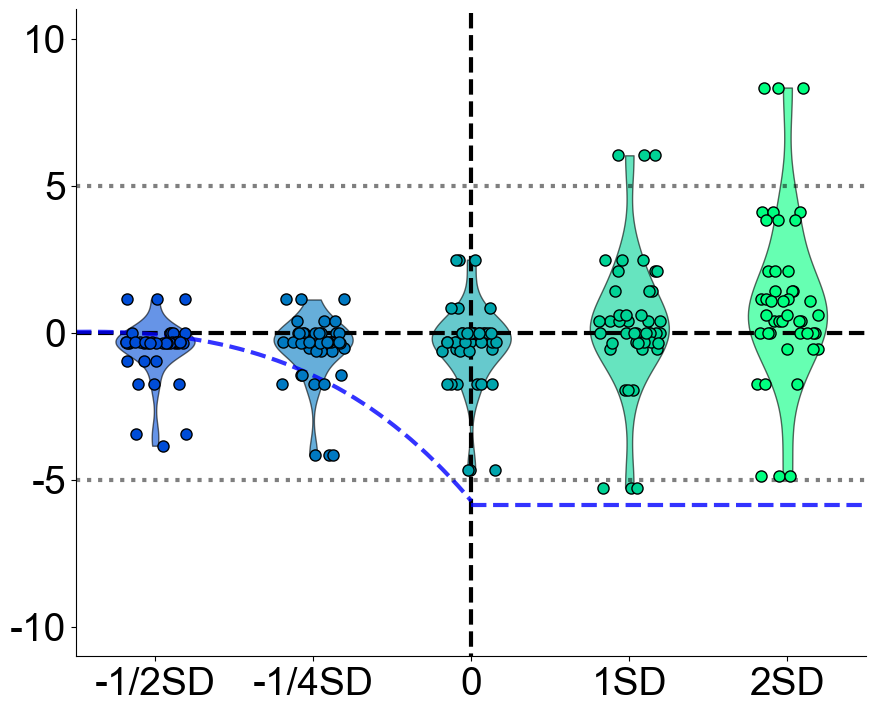

In [39]:
# Speed Shifts
print("\n--- Speed Shift Analysis ---")
shift, shift_s_speed, relSpd, speed_t, ixs_groups = calculate_speed_shifts(pmeanfire1, spmeanfire1, vector_subtract)
plot_speed_shift_summary(shift_s_speed, relSpd, speed_t, ixs_groups, figS, line_w, f_font1, sp)